# Airbnb Paris Listings Analysis

## Project Overview

This project explores the Airbnb listings dataset for Paris to understand the key factors influencing listing prices, spatial distribution, and host behavior. The analysis focuses on uncovering patterns in pricing, location, property characteristics, and reviews to derive meaningful business insights.

The goal is to move beyond basic exploratory analysis and identify **what drives pricing differences across listings and neighborhoods**, as well as how supply is distributed across the city.

---

## Objectives

- Analyze the distribution of Airbnb prices across different neighbourhoods  
- Understand how listing characteristics (accommodates, room type, property type) impact pricing  
- Examine spatial patterns in listing density and pricing across Paris  
- Evaluate the role of reviews and host attributes in influencing listing performance  
- Handle outliers and skewness to ensure robust analysis  

---

## Dataset Description

The dataset contains detailed information about Airbnb listings in Paris, including:

- **Price-related variables**: price, price per person  
- **Location features**: neighbourhood, latitude, longitude  
- **Listing characteristics**: accommodates, room type, property type  
- **Host attributes**: host experience, superhost status  
- **Review metrics**: ratings, cleanliness, location, value  

Two versions of the dataset are used:
- **Raw dataset (`paris_listings`)**: contains all listings, including extreme values  
- **Cleaned dataset (`df_clean`)**: processed dataset with outliers handled and features engineered  

---

## Approach

The analysis follows a structured workflow:

1. **Data Cleaning & Feature Engineering**  
   - Handling missing values and unrealistic entries  
   - Outlier treatment using statistical and domain-based thresholds  
   - Creation of derived features such as price per person and log-transformed price  

2. **Exploratory Data Analysis (EDA)**  
   - Distribution analysis of price and key variables  
   - Relationship between categorical and numerical features  
   - Comparison between raw and cleaned datasets  

3. **Spatial Analysis**  
   - Visualization of listing density across Paris  
   - Identification of pricing patterns across geographic regions  

4. **Insights & Interpretation**  
   - Identifying key drivers of price  
   - Understanding supply-demand dynamics across neighborhoods  

---

## Key Questions

- Where are Airbnb listings most concentrated in Paris?  
- Which neighborhoods command the highest prices?  
- How do listing characteristics affect pricing?  
- Are pricing patterns driven more by location or property features?  
- What role do reviews and host behavior play in pricing?  

---

## Summary

This analysis aims to provide a comprehensive understanding of the Airbnb market in Paris by combining statistical analysis, visualization, and domain reasoning. The findings can help inform pricing strategies, location-based decisions, and platform-level insights.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

In [2]:
df= pd.read_csv('Listings.csv', low_memory=False, encoding='ISO-8859-1')
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [4]:
df['host_since']=pd.to_datetime(df['host_since'])

In [5]:
paris_listings = df[df['city']=='Paris'][[
    'host_since',
    'latitude',
    'longitude',
    'neighbourhood',
    'property_type',
    'room_type',
    'accommodates',
    'bedrooms',
    'price',
    'minimum_nights',
    'maximum_nights',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value',
    'host_is_superhost',
    'instant_bookable'
]]
paris_listings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   host_since                 64657 non-null  datetime64[ns]
 1   latitude                   64690 non-null  float64       
 2   longitude                  64690 non-null  float64       
 3   neighbourhood              64690 non-null  object        
 4   property_type              64690 non-null  object        
 5   room_type                  64690 non-null  object        
 6   accommodates               64690 non-null  int64         
 7   bedrooms                   51286 non-null  float64       
 8   price                      64690 non-null  int64         
 9   minimum_nights             64690 non-null  int64         
 10  maximum_nights             64690 non-null  int64         
 11  review_scores_rating       48036 non-null  float64       
 12  review_s

In [6]:
paris_listings.head(2)

,host_since,latitude,longitude,neighbourhood,property_type,room_type,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,instant_bookable
0,2011-12-03,48.88668,2.33343,Buttes-Montmartre,Entire apartment,Entire place,2,1.0,53,2,1125,100.0,10.0,10.0,10.0,f,f
1,2013-11-29,48.88617,2.34515,Buttes-Montmartre,Entire apartment,Entire place,2,1.0,120,2,1125,100.0,10.0,10.0,10.0,f,f


In [7]:
paris_listings.describe(include=[np.number])

,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value
count,64690.000000,64690.000000,64690.000000,51286.000000,64690.000000,64690.000000,6.469000e+04,48036.000000,47998.000000,47971.000000,47972.000000
mean,48.864199,2.345289,3.037997,1.369224,113.096445,5.741768,8.508504e+02,93.063931,9.206446,9.685352,9.276703
std,0.018327,0.033275,1.588766,0.952845,214.433668,44.877425,3.932168e+04,8.944810,1.107371,0.702251,0.943098
min,48.813170,2.228680,0.000000,1.000000,0.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000
25%,48.850870,2.324310,2.000000,1.000000,59.000000,1.000000,3.000000e+01,90.000000,9.000000,10.000000,9.000000
50%,48.865470,2.348180,2.000000,1.000000,80.000000,2.000000,1.125000e+03,95.000000,9.000000,10.000000,9.000000
75%,48.879100,2.370460,4.000000,2.000000,120.000000,4.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000
max,48.904910,2.467050,16.000000,50.000000,12000.000000,9999.000000,1.000000e+07,100.000000,10.000000,10.000000,10.000000


### Possible Outliers

* price
* bedrooms
* accommodates
* minimum_nights
* maximum_nights

In [8]:
paris_listings[paris_listings['maximum_nights']==10000000]

,host_since,latitude,longitude,neighbourhood,property_type,room_type,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,instant_bookable
197754,2016-04-18,48.8965,2.3434,Buttes-Montmartre,Private room in apartment,Private room,1,1.0,35,1,10000000,NaN,NaN,NaN,NaN,f,f


In [9]:
paris_listings[paris_listings['price']==12000.000000]

,host_since,latitude,longitude,neighbourhood,property_type,room_type,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,instant_bookable
36228,2015-01-05,48.83844,2.3579,Gobelins,Entire apartment,Entire place,2,1.0,12000,1,1125,100.0,10.0,10.0,10.0,f,t


In [10]:
paris_listings[paris_listings['bedrooms']==50.0].head()

,host_since,latitude,longitude,neighbourhood,property_type,room_type,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,instant_bookable
202737,2015-10-13,48.85384,2.33684,Luxembourg,Room in boutique hotel,Private room,16,50.0,48,1,400,90.0,9.0,10.0,9.0,f,f
202792,2015-10-13,48.85349,2.33692,Luxembourg,Room in boutique hotel,Private room,16,50.0,51,1,400,91.0,9.0,10.0,9.0,f,f
202793,2015-10-13,48.85358,2.33680,Luxembourg,Room in boutique hotel,Private room,16,50.0,50,1,400,92.0,9.0,10.0,10.0,f,f
202794,2015-10-13,48.85358,2.33680,Luxembourg,Room in boutique hotel,Private room,16,50.0,50,1,400,90.0,9.0,10.0,9.0,f,f
202795,2015-10-13,48.85358,2.33680,Luxembourg,Room in boutique hotel,Private room,16,50.0,48,1,400,91.0,9.0,10.0,9.0,f,f


In [11]:
paris_listings[paris_listings['accommodates']==16.0].head(5)

,host_since,latitude,longitude,neighbourhood,property_type,room_type,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,instant_bookable
48168,2016-02-22,48.86219,2.34924,Louvre,Entire apartment,Entire place,16,5.0,450,1,1125,93.0,9.0,10.0,9.0,f,f
48171,2016-02-22,48.86898,2.36018,Enclos-St-Laurent,Entire apartment,Entire place,16,6.0,343,1,1125,92.0,9.0,10.0,9.0,f,f
48177,2016-02-22,48.85017,2.34816,Pantheon,Entire apartment,Entire place,16,5.0,329,1,1125,90.0,8.0,10.0,8.0,f,f
48470,2016-01-27,48.86886,2.35363,Bourse,Entire apartment,Entire place,16,5.0,870,1,1125,87.0,9.0,10.0,9.0,f,t
48477,2016-01-27,48.87031,2.33867,Bourse,Entire apartment,Entire place,16,5.0,2400,1,1125,90.0,10.0,10.0,9.0,f,t


In [12]:
paris_listings['is_large_listing'] = paris_listings['accommodates'] >= 8

In [13]:
paris_listings[paris_listings['is_large_listing']==True]

,host_since,latitude,longitude,neighbourhood,property_type,room_type,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,instant_bookable,is_large_listing
8549,2015-05-23,48.89011,2.34674,Buttes-Montmartre,Entire apartment,Entire place,8,2.0,6742,2,1125,97.0,10.0,9.0,10.0,f,f,True
8550,2014-04-20,48.86087,2.38932,Menilmontant,Entire apartment,Entire place,8,2.0,113,2,1125,91.0,9.0,9.0,9.0,f,f,True
8578,2014-08-05,48.86423,2.34861,Bourse,Entire apartment,Entire place,9,2.0,160,2,1125,90.0,8.0,9.0,8.0,f,f,True
8611,2015-07-21,48.85179,2.39289,Popincourt,Entire apartment,Entire place,9,2.0,150,3,1125,95.0,9.0,10.0,9.0,f,f,True
8768,2014-03-01,48.85188,2.29868,Vaugirard,Entire apartment,Entire place,8,2.0,250,3,1125,99.0,10.0,10.0,10.0,f,f,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273605,2016-06-27,48.82932,2.36839,Gobelins,Entire apartment,Entire place,8,2.0,90,6,10,NaN,NaN,NaN,NaN,f,t,True
273645,2013-09-21,48.87522,2.37372,Buttes-Chaumont,Entire apartment,Entire place,8,2.0,130,7,45,NaN,NaN,NaN,NaN,f,f,True
273739,2015-05-20,48.86990,2.35679,Enclos-St-Laurent,Entire apartment,Entire place,8,2.0,95,5,120,96.0,10.0,9.0,10.0,f,f,True
273877,2012-06-16,48.82634,2.35761,Gobelins,Entire apartment,Entire place,8,2.0,250,3,10,95.0,9.0,10.0,9.0,f,f,True


In [14]:
df_clean = paris_listings.copy()

In [15]:
# upper_limit = df_clean['price'].quantile(0.999)

df_clean = df_clean[df_clean['price'] <= 1000]

Outlier handling was guided by both statistical analysis and domain understanding.

While percentile-based filtering removed a large portion of high-priced listings, further inspection revealed that listings in the 600–1000 range represented a valid premium segment.

Therefore, a manual threshold of 1000 was applied, removing only extreme anomalies (~0.36% of data) while preserving meaningful variation in the luxury segment.

In [16]:
df_clean.describe()

,host_since,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value
count,64465,64498.000000,64498.000000,64498.000000,51104.000000,64498.000000,64498.000000,6.449800e+04,47943.000000,47905.000000,47878.000000,47879.000000
mean,2015-10-31 03:40:10.964089088,48.864196,2.345338,3.027474,1.364962,105.732503,5.732147,8.509327e+02,93.069770,9.206596,9.685597,9.277282
min,2008-08-30 00:00:00,48.813170,2.228680,0.000000,1.000000,0.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000
25%,2014-03-08 00:00:00,48.850842,2.324390,2.000000,1.000000,59.000000,1.000000,3.000000e+01,90.000000,9.000000,10.000000,9.000000
50%,2015-07-06 00:00:00,48.865470,2.348230,2.000000,1.000000,80.000000,2.000000,1.125000e+03,95.000000,9.000000,10.000000,9.000000
75%,2017-05-25 00:00:00,48.879117,2.370540,4.000000,2.000000,120.000000,4.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000
max,2021-02-07 00:00:00,48.904910,2.467050,16.000000,50.000000,1000.000000,9999.000000,1.000000e+07,100.000000,10.000000,10.000000,10.000000
std,NaN,0.018336,0.033273,1.560792,0.947377,93.325470,44.890369,3.938015e+04,8.928285,1.106928,0.700903,0.941995


In [17]:
df_clean = df_clean[df_clean['bedrooms'] <= 10]

In [18]:
df_clean = df_clean[df_clean['minimum_nights'] <= 90]

In [19]:
df_clean['maximum_nights'].value_counts()

maximum_nights
1125    29123
30       3035
15       1748
7        1365
365      1307
        ...  
239         1
182         1
144         1
336         1
1119        1
Name: count, Length: 218, dtype: int64

In [20]:
df_clean.drop(columns=['maximum_nights'], inplace=True)

Minimum nights was retained as it reflects booking constraints that may influence pricing.

Maximum nights was excluded/treated separately due to the presence of placeholder values (e.g., 1125), which do not represent meaningful constraints.

In [21]:
df_clean['price_per_person'] = df_clean['price'] / df_clean['accommodates']

df_clean['host_experience'] = 2026 - df_clean['host_since'].dt.year

df_clean['is_luxury'] = df_clean['price'] > df_clean['price'].quantile(0.997)

In [22]:
df_clean['price'].quantile(0.997)

800.0

In [23]:
df_clean.shape

(50722, 20)

In [24]:
paris_listings.shape

(64690, 18)

Text(0.5, 1.0, 'Before Cleaning')

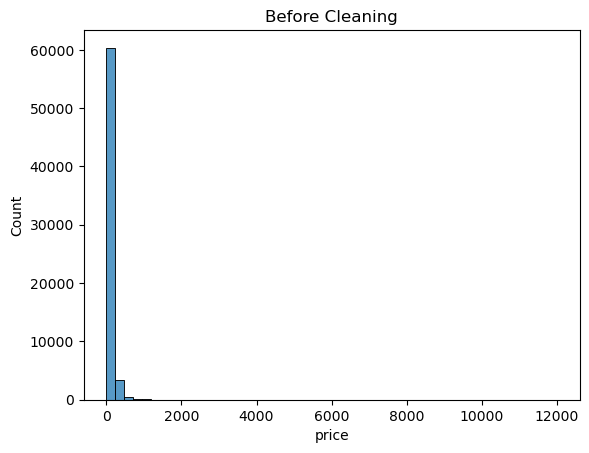

In [25]:
sns.histplot(paris_listings['price'], bins=50)
plt.title("Before Cleaning")

Text(0.5, 1.0, 'After Cleaning')

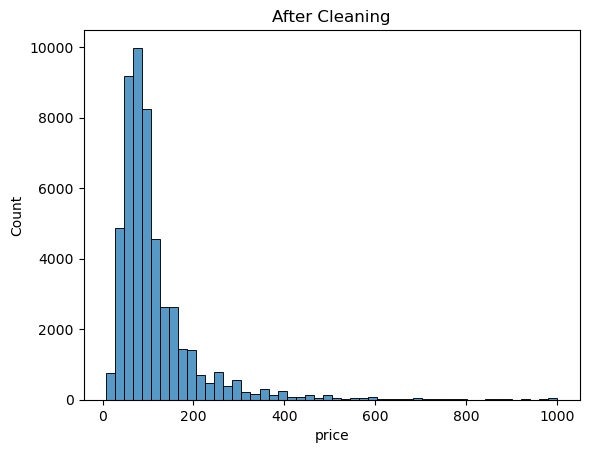

In [26]:
sns.histplot(df_clean['price'], bins=50)
plt.title("After Cleaning")

The price distribution is right-skewed, which is typical for real-world pricing data.

## Outlier Handling

Outliers were handled using a combination of statistical (IQR) and domain-based filtering:

- Price: Filtered using IQR to remove extreme values
- Bedrooms: Removed unrealistic entries (e.g., 50 bedrooms)
- Minimum/Maximum nights: Capped to realistic booking ranges

Valid large listings (e.g., accommodates up to 16) were retained to preserve meaningful variation.

## Categorical-Categorical Analysis

In [27]:
df_clean['nights_bin'] = pd.cut(
    df_clean['minimum_nights'],
    bins=[0, 3, 7, 30, 100]
)

In [28]:
pd.crosstab(df_clean['nights_bin'],df_clean['host_is_superhost'],normalize='index')*100

host_is_superhost,f,t
nights_bin,,
"(0, 3]",86.160128,13.839872
"(3, 7]",87.777294,12.222706
"(7, 30]",88.126984,11.873016
"(30, 100]",93.898305,6.101695


### Minimum Nights vs Superhost Status

Analysis of minimum stay requirements shows:

- Short stays (1–3 nights) have the highest proportion of superhosts.
- As minimum stay duration increases, the proportion of superhosts declines.

This suggests that:
- Superhosts may prioritize shorter stays to maximize booking frequency and reviews.
- Longer minimum stays are more common among less active or less optimized hosts.

In [29]:
df_clean['accommodation_size'] = pd.cut(
    df_clean['accommodates'],
    bins=[1,2,4,8,16],
    labels=['Solo','Couple','Family','Group']
)

<Axes: xlabel='accommodation_size', ylabel='room_type'>

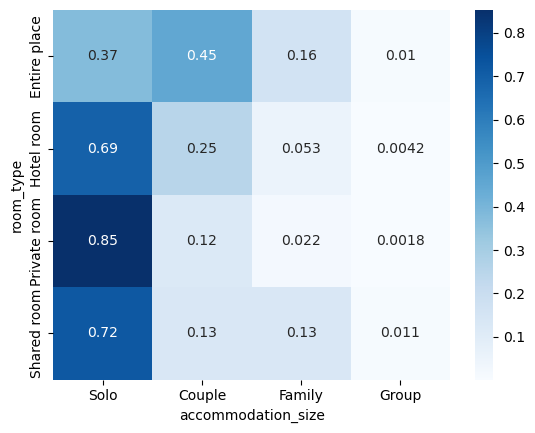

In [30]:
ct = pd.crosstab(
    df_clean['room_type'],
    df_clean['accommodation_size'],
    normalize='index'
)

sns.heatmap(ct, annot=True, cmap='Blues')

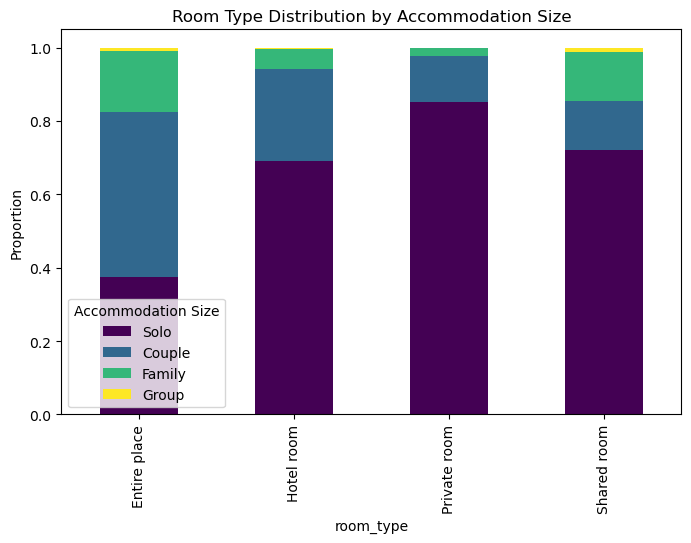

In [31]:
ct.plot(kind='bar', stacked=True, figsize=(8,5), colormap='viridis')
plt.title('Room Type Distribution by Accommodation Size')
plt.ylabel('Proportion')
plt.legend(title='Accommodation Size')
plt.show()

### Room Type Distribution Across Accommodation Sizes

The relationship between room type and accommodation size reveals strong structural patterns:

- **Entire places** are primarily suited for couples and small families, with a balanced distribution across accommodation sizes.
- **Private rooms** are overwhelmingly designed for solo travelers (~85%), indicating budget-oriented offerings.
- **Hotel rooms** also cater mainly to solo travelers but show slightly more diversity than private rooms.
- **Shared rooms** display a mixed distribution but remain a niche category overall.

This suggests clear market segmentation:
- Private/shared rooms → individual travelers
- Entire places → group or family stays

<Axes: ylabel='neighbourhood'>

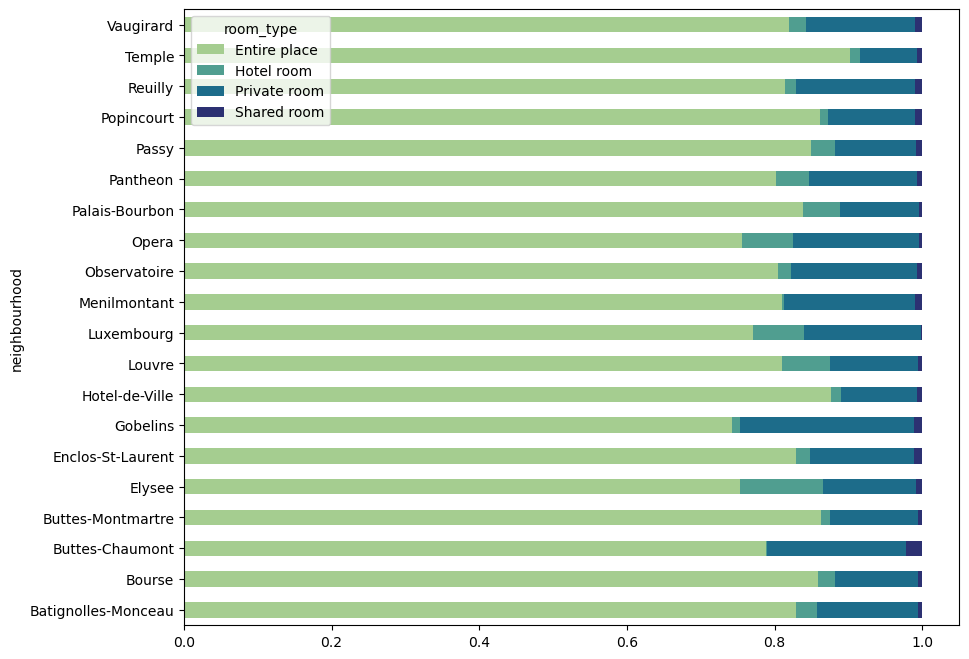

In [32]:
ct = pd.crosstab(
    df_clean['neighbourhood'],
    df_clean['room_type'],
    normalize='index'
)

ct.plot(kind='barh', stacked=True, figsize=(10,8), colormap='crest')

### Room Type Distribution Across Neighbourhoods

Across most neighbourhoods, listings are dominated by **entire places**, indicating a strong preference for full-property rentals in Paris.

- Central and premium areas tend to have a higher proportion of entire homes.
- Peripheral or high-density areas show slightly more **private room availability**, suggesting affordability-driven supply.

Overall, the Paris Airbnb market is heavily skewed toward entire property rentals rather than shared or partial accommodations.

In [33]:
top_types = df_clean['property_type'].value_counts().head(10).index

df_top = df_clean[df_clean['property_type'].isin(top_types)]

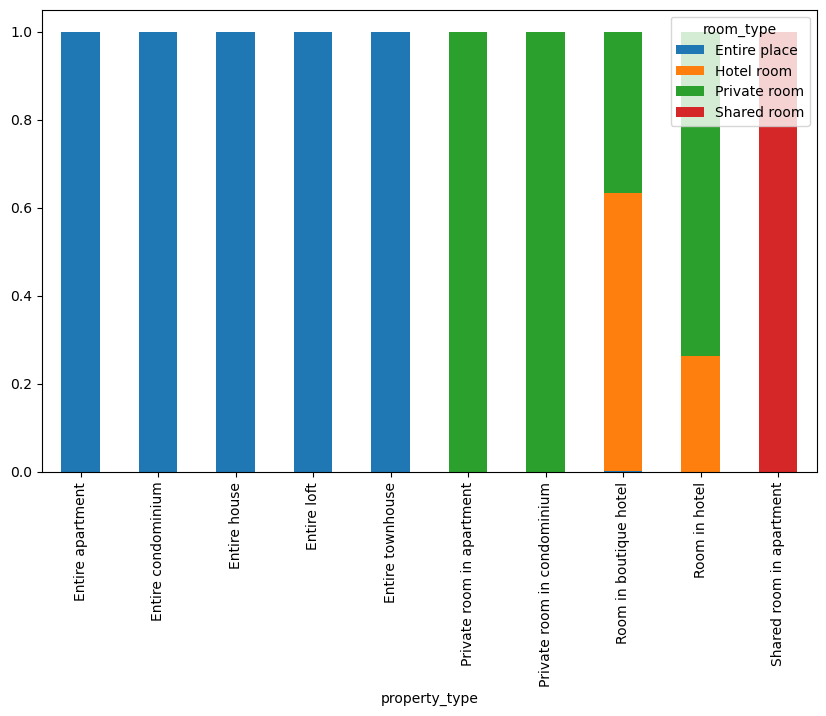

In [34]:
ct = pd.crosstab(
    df_top['property_type'],
    df_top['room_type'],
    normalize='index'
)

ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xticks(rotation=90)
plt.show()

### Room Type Composition Across Property Types

Different property types exhibit highly distinct room type structures:

- Entire apartments, houses, and lofts are almost exclusively listed as **entire places**, reflecting full-property rentals.
- Boutique hotels and hotel rooms show a mix of **hotel rooms and private rooms**, indicating hospitality-driven listings.
- Some niche property types (e.g., shared accommodations) are dominated by **shared room listings**.

This highlights that property type strongly determines how a listing is marketed and consumed.

In [35]:
ct = pd.crosstab(
    df_clean['neighbourhood'],
    df_clean['instant_bookable'],
    normalize='index'
)*100

#ct.plot(kind='bar', stacked=True, colormap='magma')
ct

instant_bookable,f,t
neighbourhood,,
Batignolles-Monceau,68.830787,31.169213
Bourse,56.265060,43.734940
Buttes-Chaumont,74.608866,25.391134
Buttes-Montmartre,74.062661,25.937339
Elysee,54.088953,45.911047
Enclos-St-Laurent,70.308725,29.691275
Gobelins,69.235033,30.764967
Hotel-de-Ville,60.941828,39.058172
Louvre,57.681693,42.318307


In [36]:
ct = pd.crosstab(
    df_clean['room_type'],
    df_clean['instant_bookable'],
    normalize='index'
)*100

#ct.plot(kind='bar', stacked=True, colormap='magma')
ct

instant_bookable,f,t
room_type,,
Entire place,71.226855,28.773145
Hotel room,5.804954,94.195046
Private room,63.641449,36.358551
Shared room,64.858491,35.141509


### Instant Booking Behavior by Room Type

Room type emerges as the strongest driver of instant booking availability:

- **Hotel rooms** exhibit extremely high instant booking adoption (~90%+), reflecting standardized, professional operations.
- **Entire places** show moderate adoption (~25–30%), indicating host-controlled booking decisions.
- **Private and shared rooms** fall in between, balancing flexibility and control.

This highlights a clear distinction between:
- **Professional listings (hotel-like)** → highly automated  
- **Individual hosts (entire homes)** → more selective booking behavior

In [37]:
ct = pd.crosstab(
    df_top['property_type'],
    df_top['instant_bookable'],
    normalize='index'
)*100

ct

instant_bookable,f,t
property_type,,
Entire apartment,71.255697,28.744303
Entire condominium,70.606293,29.393707
Entire house,71.197411,28.802589
Entire loft,77.409326,22.590674
Entire townhouse,77.419355,22.580645
Private room in apartment,74.260968,25.739032
Private room in condominium,69.965870,30.034130
Room in boutique hotel,4.649758,95.350242
Room in hotel,11.244980,88.755020


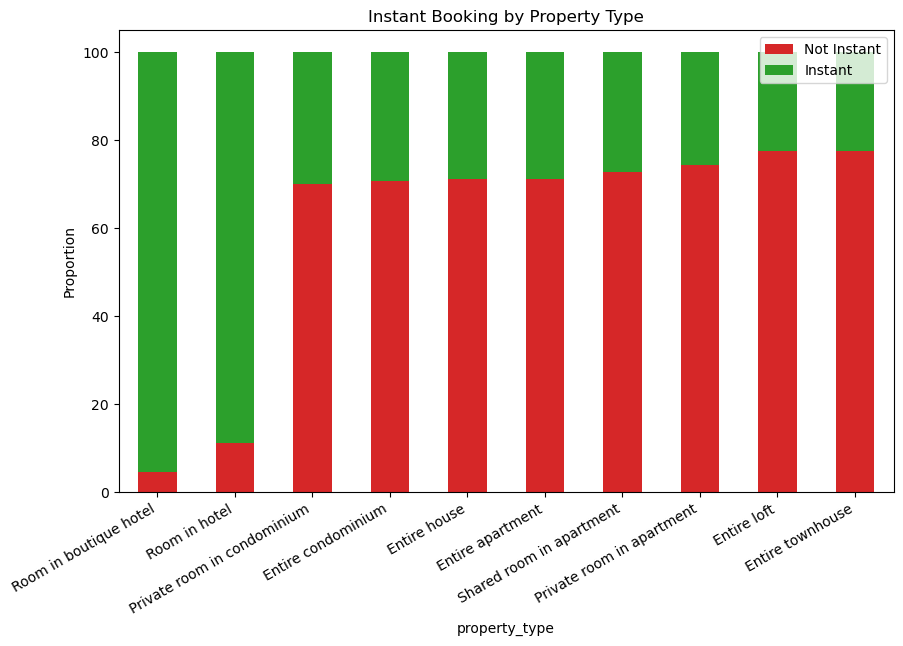

In [38]:
ct = pd.crosstab(
    df_top['property_type'],
    df_top['instant_bookable'],
    normalize='index'
)*100

ct = ct.sort_values(by = 't', ascending=False)

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['#d62728', '#2ca02c']
)

plt.title('Instant Booking by Property Type')
plt.ylabel('Proportion')
plt.xticks(rotation=30, ha='right')
plt.legend(['Not Instant', 'Instant'])
plt.show()

### Instant Booking Availability by Property Type

Instant booking availability varies significantly across property types:

- Standard residential listings (apartments, houses) have moderate instant booking adoption.
- Hospitality-oriented listings (e.g., boutique hotels) show higher instant booking rates.
- Some niche property types exhibit very low instant booking availability, suggesting higher host control.

This indicates operational differences between individual hosts and professionally managed listings.

## Categorical-Numerical Analysis

<Axes: xlabel='accommodates', ylabel='price'>

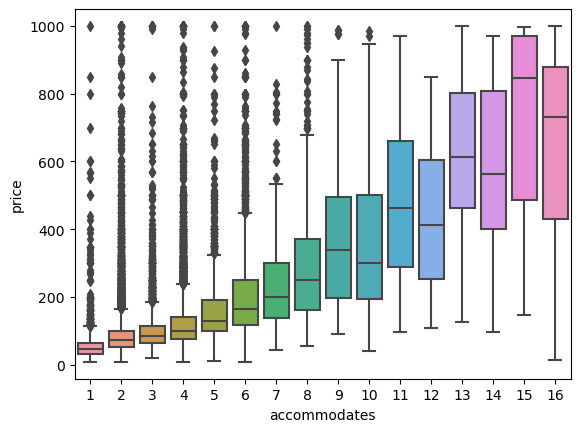

In [39]:
sns.boxplot(x='accommodates', y='price', data=df_clean)

<Axes: xlabel='accommodation_size', ylabel='price'>

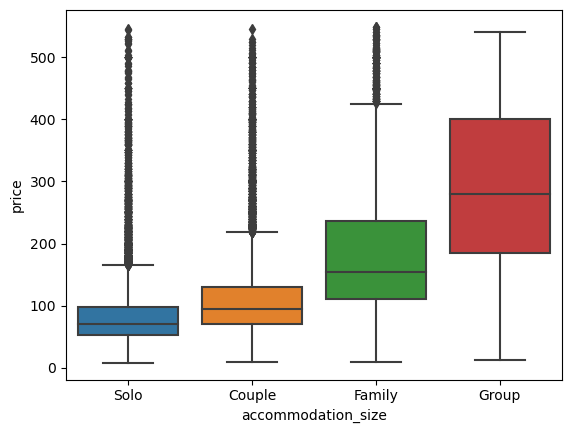

In [40]:
sns.boxplot(x='accommodation_size', y='price', data=df_clean[df_clean['price'] < df_clean['price'].quantile(0.99)])

Larger listings (Group) command higher prices on average, but also exhibit high variability, indicating a mix of budget and luxury group accommodations.

<Axes: xlabel='accommodation_size', ylabel='price_per_person'>

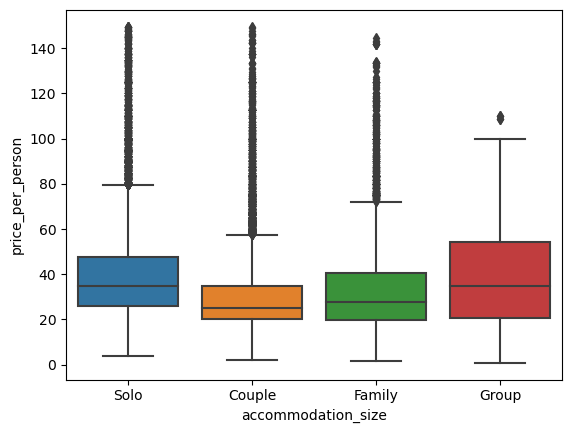

In [41]:
sns.boxplot(x='accommodation_size', y='price_per_person', data=df_clean[df_clean['price_per_person'] < df_clean['price_per_person'].quantile(0.99)])

In [42]:
df_clean.groupby('accommodation_size')['price_per_person'].mean()

accommodation_size
Solo      43.320926
Couple    31.321283
Family    33.426526
Group     39.090975
Name: price_per_person, dtype: float64

Price per person follows a non-linear pattern across accommodation sizes.

While costs decrease from solo to couple and family listings, group accommodations exhibit a higher median price per person. This suggests that larger listings are often premium properties, where higher total costs offset the benefit of cost-sharing.

This highlights that larger capacity does not always imply lower per-person cost, especially in high-end segments.

<Axes: xlabel='room_type', ylabel='price_per_person'>

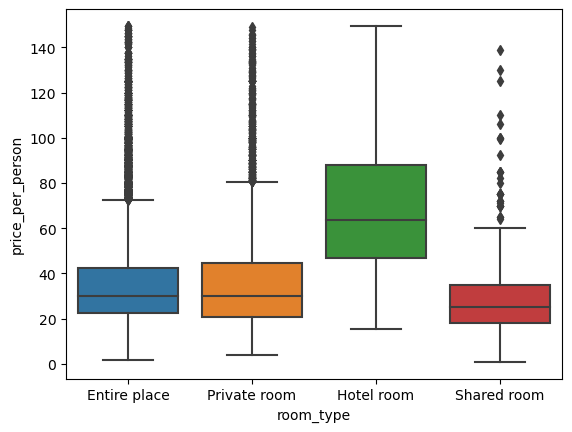

In [43]:
sns.boxplot(x='room_type', y='price_per_person', data=df_clean[df_clean['price_per_person'] < df_clean['price_per_person'].quantile(0.99)])

In [44]:
df_clean.groupby('room_type')['price_per_person'].median()

room_type
Entire place    30.0
Hotel room      70.0
Private room    30.0
Shared room     25.0
Name: price_per_person, dtype: float64

Hotel rooms exhibit the highest price per person, while shared rooms are the most economical.

Entire homes, despite higher absolute prices, offer better cost efficiency when shared among multiple guests.

In [45]:
paris_listings['host_experience'] = 2026 - paris_listings['host_since'].dt.year

In [46]:
paris_listings['price_per_person'] = paris_listings['price'] / paris_listings['accommodates']

In [47]:
paris_listings['is_luxury'] = paris_listings['price'] > paris_listings['price'].quantile(0.9945)

In [48]:
paris_listings['price'].quantile(0.9945)

800.8420000000042

In [49]:
df_clean_neighbourhood=df_clean.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).to_frame()
df_clean_neighbourhood.head()

,price
neighbourhood,
Elysee,209.296987
Louvre,170.909844
Luxembourg,165.883539
Palais-Bourbon,164.814456
Passy,159.677044


In [50]:
paris_listings_neighbourhood=paris_listings.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).to_frame()
paris_listings_neighbourhood.head()

,price
neighbourhood,
Elysee,210.536765
Louvre,175.379972
Passy,161.144635
Palais-Bourbon,156.856578
Luxembourg,155.638639


While both Passy and Luxembourg rank among the most expensive neighbourhoods, their positioning shifts after outlier removal.

Passy’s earlier ranking was influenced by high-end luxury listings, whereas Luxembourg maintains a higher position due to consistently strong pricing across listings.

This highlights the difference between luxury-driven pricing and uniformly high market pricing.

In [51]:
paris_listings[(paris_listings['neighbourhood']=='Passy') & (paris_listings['price']>1000) ].head(8)

,host_since,latitude,longitude,neighbourhood,property_type,room_type,accommodates,bedrooms,price,minimum_nights,...,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,instant_bookable,is_large_listing,host_experience,price_per_person,is_luxury
9868,2019-07-25,48.87042,2.28968,Passy,Entire apartment,Entire place,2,1.0,1100,2,...,91.0,8.0,10.0,9.0,f,f,False,7.0,550.000000,True
38154,2015-01-10,48.87013,2.28265,Passy,Entire apartment,Entire place,8,3.0,1490,7,...,98.0,10.0,10.0,9.0,f,f,True,11.0,186.250000,True
41214,2016-03-07,48.87249,2.28177,Passy,Entire apartment,Entire place,6,3.0,1200,3,...,NaN,NaN,NaN,NaN,f,t,False,10.0,200.000000,True
49384,2019-05-21,48.85642,2.28609,Passy,Entire apartment,Entire place,6,3.0,3500,4,...,NaN,NaN,NaN,NaN,f,f,False,7.0,583.333333,True
57208,2019-06-10,48.86499,2.28729,Passy,Entire apartment,Entire place,10,4.0,1550,10,...,NaN,NaN,NaN,NaN,f,f,True,7.0,155.000000,True
81449,2009-09-06,48.85531,2.27624,Passy,Entire townhouse,Entire place,16,5.0,2000,2,...,99.0,10.0,10.0,10.0,t,f,True,17.0,125.000000,True
82678,2017-05-25,48.86896,2.28473,Passy,Entire house,Entire place,8,4.0,1200,6,...,NaN,NaN,NaN,NaN,f,f,True,9.0,150.000000,True
82679,2019-08-07,48.86451,2.27783,Passy,Entire house,Entire place,4,2.0,2500,3,...,NaN,NaN,NaN,NaN,f,t,False,7.0,625.000000,True


Passy appears among the most expensive neighbourhoods in the raw dataset due to a concentration of high-priced luxury listings.

However, after removing extreme price values, it no longer ranks among the top 3, indicating that its pricing is driven by a smaller segment of premium properties rather than consistently high prices across listings.

In [52]:
paris_listings[paris_listings['neighbourhood'] == 'Passy']['price'].describe()

count     3215.000000
mean       161.144635
std        341.267907
min          0.000000
25%         69.000000
50%        100.000000
75%        160.000000
max      10250.000000
Name: price, dtype: float64

In [53]:
df_clean[df_clean['neighbourhood'] == 'Passy']['price'].describe()

count    2409.000000
mean      159.677044
std       136.597130
min         8.000000
25%        80.000000
50%       118.000000
75%       190.000000
max      1000.000000
Name: price, dtype: float64

After removing extreme price outliers, the maximum price in Passy decreased significantly.

Interestingly, the upper quartiles increased slightly, indicating that the original distribution was heavily skewed by extreme values.

The cleaned data provides a more accurate representation of typical pricing in the neighbourhood.

In [54]:
paris_listings[(paris_listings['neighbourhood']=='Luxembourg') & (paris_listings['price']>1000) ].head(6)

,host_since,latitude,longitude,neighbourhood,property_type,room_type,accommodates,bedrooms,price,minimum_nights,...,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_is_superhost,instant_bookable,is_large_listing,host_experience,price_per_person,is_luxury
22375,2019-05-20,48.85018,2.32533,Luxembourg,Entire apartment,Entire place,2,1.0,2000,4,...,73.0,7.0,7.0,7.0,f,t,False,7.0,1000.000000,True
32224,2015-04-11,48.85404,2.33050,Luxembourg,Entire apartment,Entire place,5,3.0,1200,3,...,100.0,10.0,10.0,10.0,f,t,False,11.0,240.000000,True
48455,2016-01-27,48.84356,2.33177,Luxembourg,Entire apartment,Entire place,11,3.0,2299,1,...,86.0,9.0,10.0,9.0,f,t,True,10.0,209.000000,True
48490,2016-01-27,48.85099,2.34255,Luxembourg,Entire apartment,Entire place,15,4.0,1073,1,...,86.0,8.0,10.0,9.0,f,t,True,10.0,71.533333,True
61262,2019-09-12,48.84211,2.33711,Luxembourg,Entire apartment,Entire place,6,3.0,1299,1,...,NaN,NaN,NaN,NaN,f,f,False,7.0,216.500000,True
151213,2019-05-27,48.85424,2.33263,Luxembourg,Room in boutique hotel,Hotel room,2,1.0,1010,1,...,NaN,NaN,NaN,NaN,f,t,False,7.0,505.000000,True


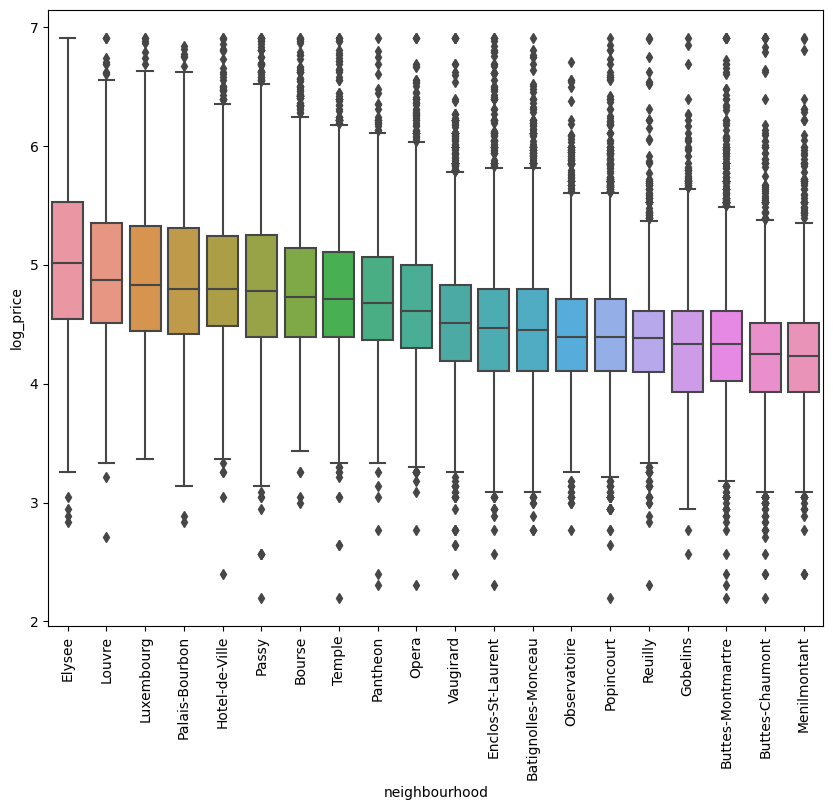

In [55]:
plt.figure(figsize=(10,8))
order = df_clean.groupby('neighbourhood')['price'].median().sort_values(ascending=False).index


df_clean['log_price'] = np.log1p(df_clean['price'])

sns.boxplot(
    x='neighbourhood',
    y='log_price',
    data=df_clean,
    order=order
)
plt.xticks(rotation=90)
plt.show()

### Price Distribution Across Top Neighbourhoods (Log-Transformed)

To better understand pricing patterns across the most expensive neighbourhoods, a log transformation was applied to the `price` variable. This was necessary due to the highly right-skewed nature of the original price distribution, where a small number of premium listings distorted the visual interpretation.

The log-transformed boxplot reveals several important insights:

* **Consistently Expensive Neighbourhoods:**
  Neighbourhoods such as *Elysee*, *Louvre*, and *Luxembourg* exhibit higher median prices with relatively tighter interquartile ranges. This indicates that listings in these areas are consistently priced at a higher level, reflecting strong and stable demand.

* **Luxury-Driven Neighbourhoods:**
  *Passy*, while still among the top neighbourhoods, shows a wider spread in its price distribution. This suggests that its higher average pricing is influenced by a subset of premium or luxury listings rather than uniformly high prices across all properties.

* **Mid-Range Premium Areas:**
  Neighbourhoods like *Temple*, *Opera*, and *Pantheon* display comparatively lower median prices with moderate variability, indicating a more balanced mix of mid-range listings.

* **Reduced Visual Distortion:**
  The log transformation compresses extreme values and reduces skewness, allowing for clearer comparison across neighbourhoods without removing meaningful data.

Overall, this analysis highlights that not all high-priced neighbourhoods behave similarly—some maintain consistently high pricing, while others are driven by a smaller segment of luxury listings. This distinction is crucial for understanding market segmentation within the Paris Airbnb landscape.


In [56]:
df1=df_clean.groupby(['neighbourhood','accommodation_size'])['price'].mean().sort_values(ascending=False).reset_index()
df1[df1['accommodation_size']=='Family']['price'].head().mean()

285.426730435903

In [57]:
df_clean.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).reset_index()['price'].head().mean()

174.1163741017412

In [58]:
((285.426730435903-174.1163741017412)/174.1163741017412)*100

63.92871256848017

## Impact of Accommodation Size in Premium Neighbourhoods
   * In the top 5 most expensive neighbourhoods, listings accommodating **4 or more guests** are priced **~64%** higher than the overall average listing price within these neighbourhoods.
   * This indicates that **accommodation capacity is a major driver of pricing**, especially in high-demand areas.
   * The premium reflects:
        * Higher space and amenity offerings
        * Suitability for families and group travelers
        * Increased willingness to pay for shared accommodation in prime locations

<Axes: xlabel='nights_bin', ylabel='log_price'>

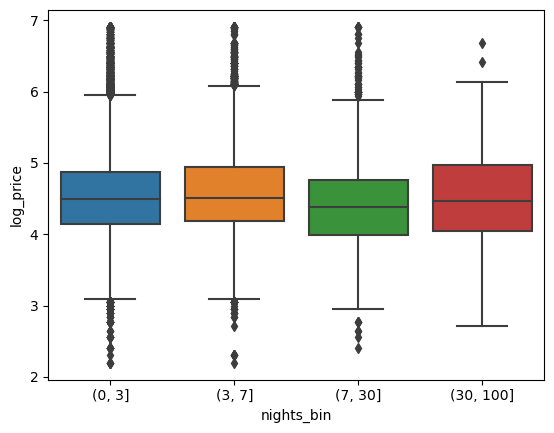

In [59]:
df_clean['nights_bin'] = pd.cut(df_clean['minimum_nights'], bins=[0,3,7,30,100])

sns.boxplot(x='nights_bin', y='log_price', data=df_clean)

<Axes: xlabel='room_type', ylabel='log_price'>

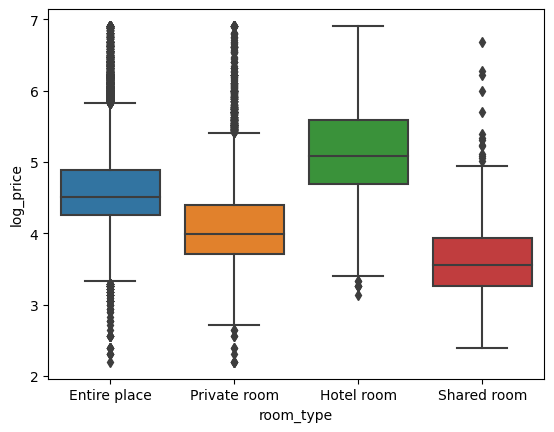

In [60]:
sns.boxplot(x='room_type', y='log_price', data=df_clean)

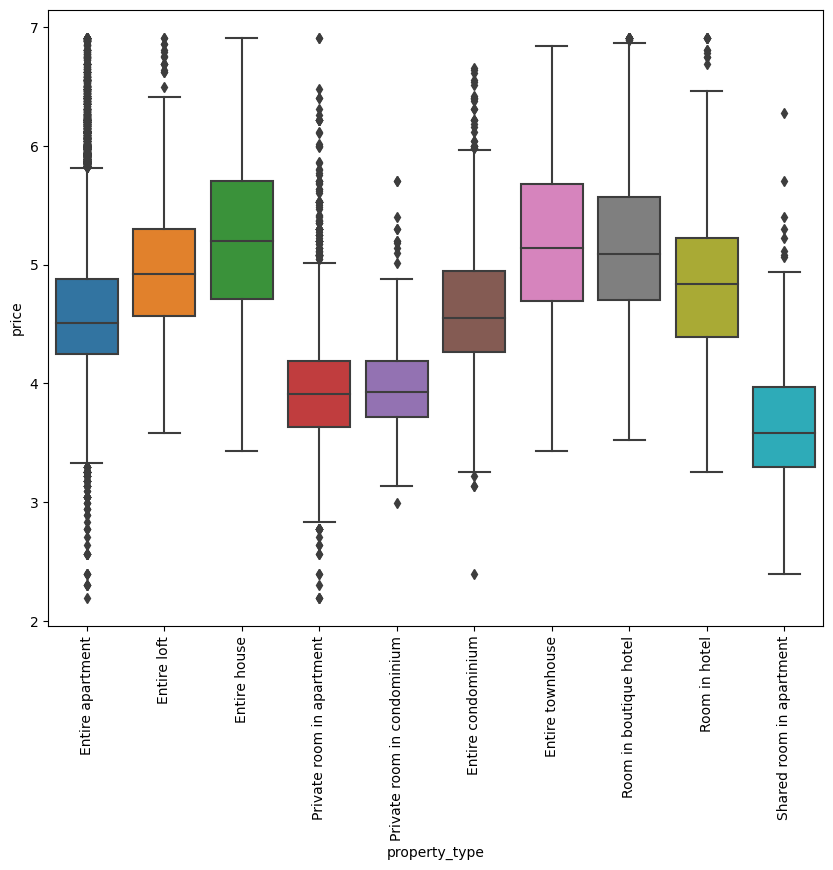

In [61]:
plt.figure(figsize=(10,8))
sns.boxplot(x=df_top['property_type'], y=np.log1p(df_top['price']))
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='host_is_superhost', ylabel='review_scores_rating'>

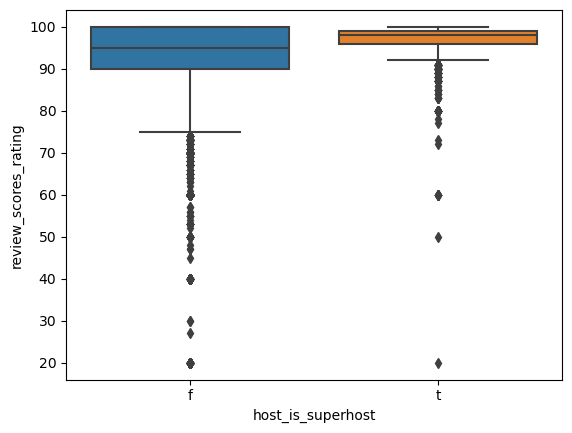

In [62]:
sns.boxplot(x='host_is_superhost', y='review_scores_rating', data=df_clean)

* Superhosts have slightly higher ratings
* Less variance (tighter distribution)

<Axes: xlabel='review_scores_rating', ylabel='Count'>

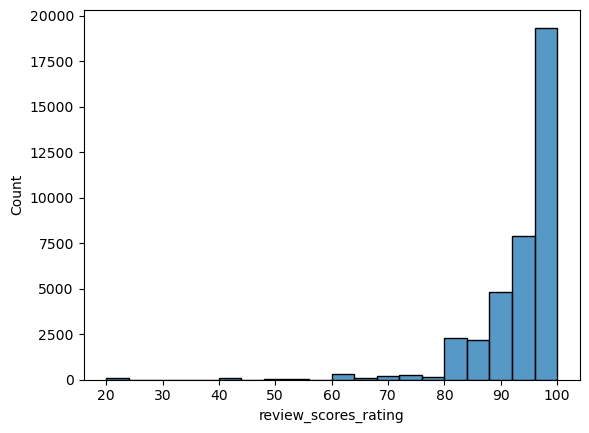

In [63]:
sns.histplot(df_clean['review_scores_rating'], bins=20)

* Heavy skew toward 90–100
* Reviews are not very informative as a differentiator

<Axes: xlabel='host_is_superhost', ylabel='log_price'>

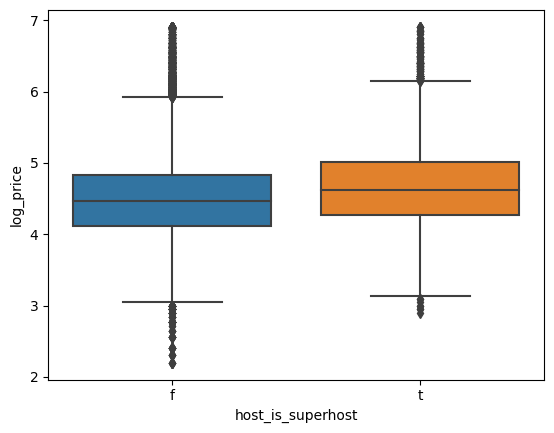

In [64]:
sns.boxplot(x='host_is_superhost', y='log_price', data=df_clean)

<Axes: xlabel='host_is_superhost', ylabel='log_price'>

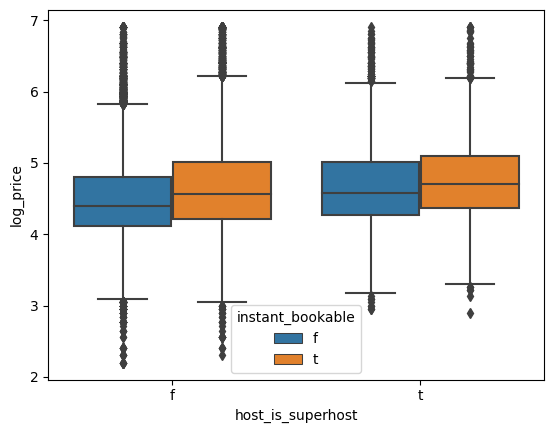

In [65]:
sns.boxplot(x='host_is_superhost', y='log_price', hue='instant_bookable',data=df_clean)

In [66]:
df_clean.groupby(['host_is_superhost','instant_bookable'])['price'].median()

host_is_superhost  instant_bookable
f                  f                    80.0
                   t                    95.0
t                  f                    96.0
                   t                   110.0
Name: price, dtype: float64

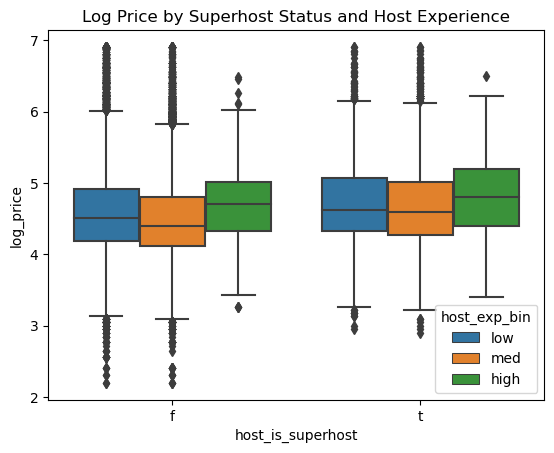

In [67]:
df_clean['host_exp_bin'] = pd.cut(
    df_clean['host_experience'],
    bins=[5,10,15,20],
    labels=['low', 'med', 'high']
)

sns.boxplot(x='host_is_superhost', y='log_price', hue='host_exp_bin',data=df_clean)
plt.title('Log Price by Superhost Status and Host Experience')
plt.show()

In [68]:
df_clean.groupby(['host_exp_bin','host_is_superhost'])['price'].median()

host_exp_bin  host_is_superhost
low           f                     90.0
              t                    101.0
med           f                     80.0
              t                     98.0
high          f                    109.0
              t                    120.0
Name: price, dtype: float64

### Host Experience vs Pricing (with Superhost Effect)
* Listings from highly experienced hosts (15+ years) have the highest median prices, confirming that extensive experience contributes to stronger pricing power.
* However, the relationship is not strictly monotonic:
    * Medium experience hosts (10–15 years) show lower median prices than even less experienced hosts (5–10 years).
    * This suggests that factors beyond experience (e.g., property type, location, or competition) may influence pricing in mid-experience ranges.
* Across all experience levels, superhosts consistently charge higher prices:
    * Low: +11
    * Medium: +18(big jump for superhosts)
    * High: +11
* The superhost premium is strongest in the medium experience group, indicating that reputation may compensate for weaker pricing power in this segment.

In [69]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('log_price ~ C(host_exp_bin) + C(host_is_superhost) + C(host_exp_bin):C(host_is_superhost)', data=df_clean).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(host_exp_bin),116.615048,2.0,158.734272,1.896391e-69
C(host_is_superhost),153.333988,1.0,417.430844,2.090561e-92
C(host_exp_bin):C(host_is_superhost),4.282589,2.0,5.829382,2.941868e-03
Residual,18587.892783,50603.0,NaN,NaN


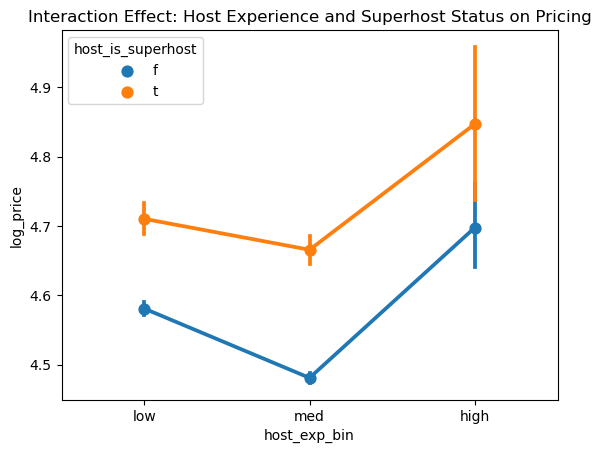

In [70]:
sns.pointplot(
    x='host_exp_bin',
    y='log_price',
    hue='host_is_superhost',
    data=df_clean
)
plt.title('Interaction Effect: Host Experience and Superhost Status on Pricing')
plt.show()

### Statistical Validation of Pricing Drivers (Two-Way ANOVA)

A two-way ANOVA was conducted to evaluate the impact of host experience and superhost status on listing prices.

   * **Host experience** has a statistically significant effect on pricing (p < 0.001), indicating that price levels vary across experience groups.
   * **Superhost status** has a highly significant impact (p < 0.001), confirming that superhosts consistently command higher prices.
   * The **interaction between host experience and superhost status is also significant** (p < 0.01):
        * This indicates that the pricing advantage of being a superhost **is not uniform across experience levels**.
        * Specifically, the **superhost premium is strongest in the medium experience group**, suggesting that reputation plays a compensatory role for mid-level hosts.

In [71]:
from scipy.stats import kruskal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def kruskal_summary(df_clean, group_col, value_col='price'):
    groups = [g[value_col].dropna().values
              for _, g in df_clean.groupby(group_col)]
    stat, p = kruskal(*groups)
    n_groups = df_clean[group_col].nunique()
    eta_sq = (stat - n_groups + 1) / (len(df_clean) - n_groups)  # effect size
    return {
        'variable':   group_col,
        'H statistic': round(stat, 2),
        'p value':    p,
        'n groups':   n_groups,
        'eta squared': round(eta_sq, 4),
        'significant': p < 0.05
    }

In [72]:
test_vars = [
    'neighbourhood',
    'room_type',
    'accommodation_size',
    'property_type',
    'host_is_superhost',
    'instant_bookable',
    'host_exp_bin'
]

results = pd.DataFrame([kruskal_summary(df_clean, v) for v in test_vars])

results['p value'] = results['p value'].map('{:.2e}'.format)
results['significant'] = results['significant'].map({True: '✓ yes', False: '✗ no'})

results

,variable,H statistic,p value,n groups,eta squared,significant
0,neighbourhood,7219.66,0.00e+00,20,0.1420,✓ yes
1,room_type,6353.97,0.00e+00,4,0.1252,✓ yes
2,accommodation_size,11436.62,0.00e+00,4,0.2254,✓ yes
3,property_type,10179.64,0.00e+00,65,0.1997,✓ yes
4,host_is_superhost,458.38,1.08e-101,2,0.0090,✓ yes
5,instant_bookable,721.28,7.04e-159,2,0.0142,✓ yes
6,host_exp_bin,351.47,4.78e-77,3,0.0069,✓ yes


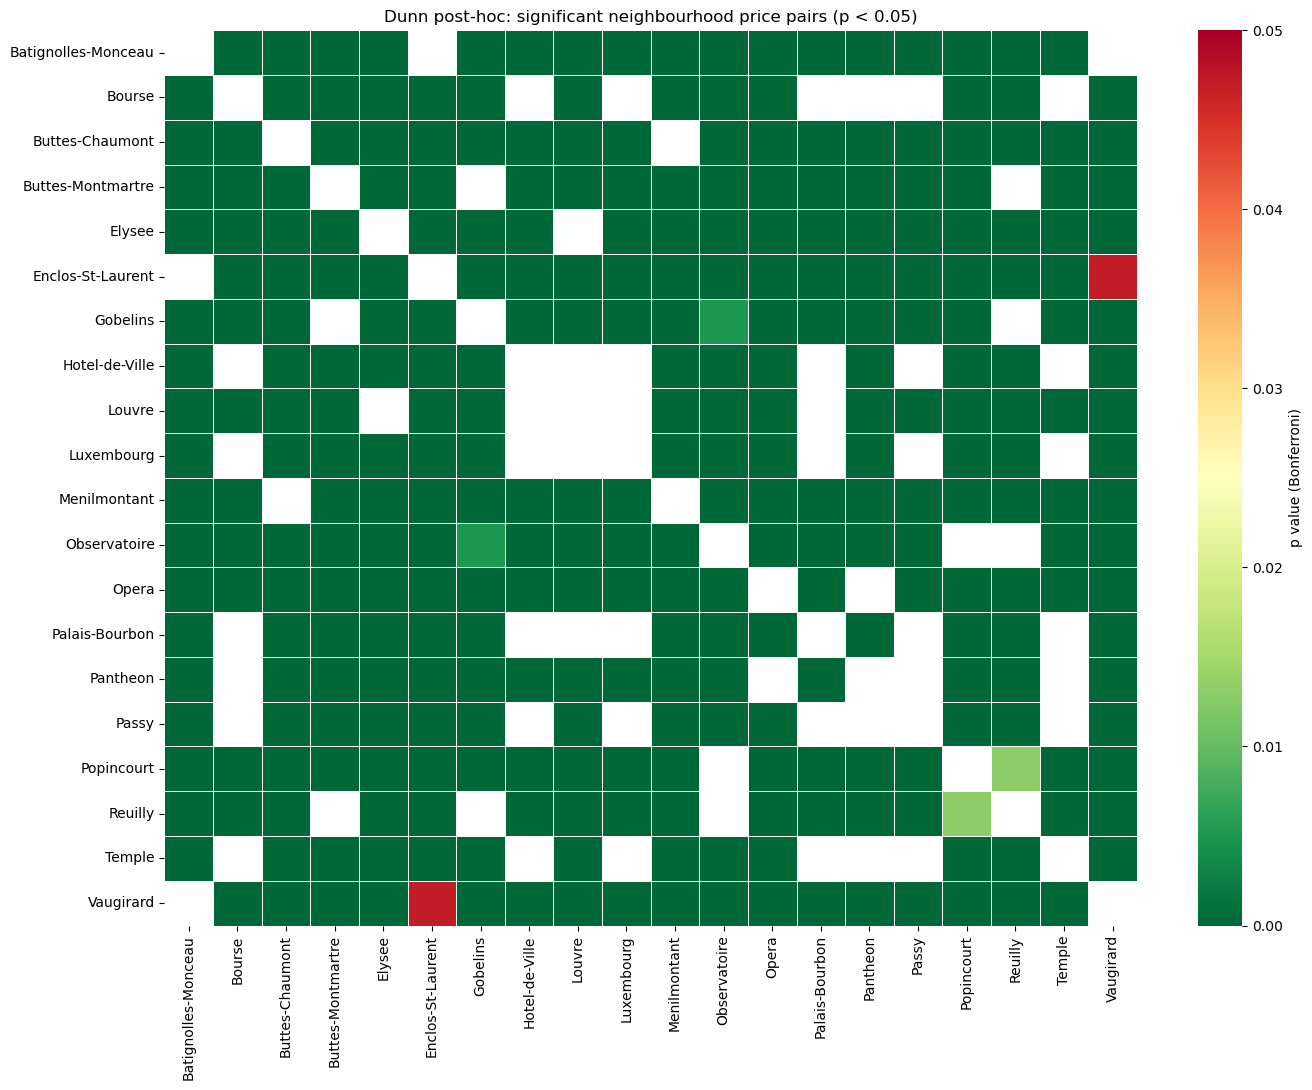

In [73]:
import scikit_posthocs as sp

dunn_neighbourhood = sp.posthoc_dunn(
    df_clean,
    val_col='price',
    group_col='neighbourhood',
    p_adjust='bonferroni'
)

sig_mask = dunn_neighbourhood > 0.05

plt.figure(figsize=(14, 11))
sns.heatmap(
    dunn_neighbourhood,
    mask=sig_mask,
    cmap='RdYlGn_r',
    vmin=0, vmax=0.05,
    linewidths=0.4,
    annot=False,
    cbar_kws={'label': 'p value (Bonferroni)'}
)
plt.title('Dunn post-hoc: significant neighbourhood price pairs (p < 0.05)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

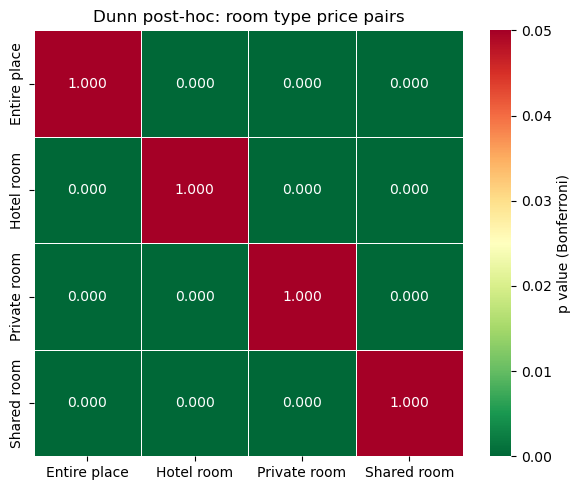

room_type
Hotel room      160.0
Entire place     90.0
Private room     53.0
Shared room      34.0
Name: price, dtype: float64

In [74]:
dunn_room = sp.posthoc_dunn(
    df_clean,
    val_col='price',
    group_col='room_type',
    p_adjust='bonferroni'
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    dunn_room,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn_r',
    vmin=0, vmax=0.05,
    linewidths=0.5,
    cbar_kws={'label': 'p value (Bonferroni)'}
)
plt.title('Dunn post-hoc: room type price pairs')
plt.tight_layout()
plt.show()

df_clean.groupby('room_type')['price'].median().sort_values(ascending=False)

In [75]:
# eta squared benchmarks: small=0.01, medium=0.06, large=0.14
def eta_label(e):
    if e < 0.01:   return 'negligible'
    elif e < 0.06:  return 'small'
    elif e < 0.14:  return 'medium'
    else:           return 'large'

raw_results = [kruskal_summary(df_clean, v) for v in test_vars]
for r in raw_results:
    r['effect size'] = eta_label(r['eta squared'])

effect_df = pd.DataFrame(raw_results)[['variable', 'eta squared', 'effect size']]
effect_df.sort_values('eta squared', ascending=False)

,variable,eta squared,effect size
2,accommodation_size,0.2254,large
3,property_type,0.1997,large
0,neighbourhood,0.1420,large
1,room_type,0.1252,medium
5,instant_bookable,0.0142,small
4,host_is_superhost,0.0090,negligible
6,host_exp_bin,0.0069,negligible


### Interpreting Effect Sizes Beyond Statistical Significance

While all variables tested using the Kruskal–Wallis procedure were statistically significant (p < 0.05), effect size analysis revealed substantial differences in their practical importance. Accommodation size, property type, neighbourhood, and room type exhibited medium to large effects on pricing, indicating that structural characteristics of the listing are the primary determinants of Airbnb prices in Paris.

In contrast, host-related attributes such as superhost status and host experience showed negligible effect sizes despite their statistically significant p-values. Given the large sample size of this dataset (≈51,000 listings), even very small differences become detectable by significance tests. Therefore, these variables should be interpreted as having measurable but limited real-world influence on pricing.

Overall, the findings suggest that **what is being offered (the property's characteristics and location) matters far more than who is offering it (the host's reputation or experience)** when explaining price variation in the Paris Airbnb market.

**Key Insight: Property characteristics explain most of the variation in Airbnb prices, whereas host-related factors contribute only marginally despite being statistically significant**.

In [76]:
df_clean_accommodates=df_clean[df_clean['neighbourhood']=='Elysee'].groupby('accommodates')['price'].median().sort_values().to_frame()

df_clean_accommodates

,price
accommodates,
1,59.0
2,111.0
3,130.0
4,150.0
7,219.5
5,226.0
6,257.0
8,356.0
9,416.0


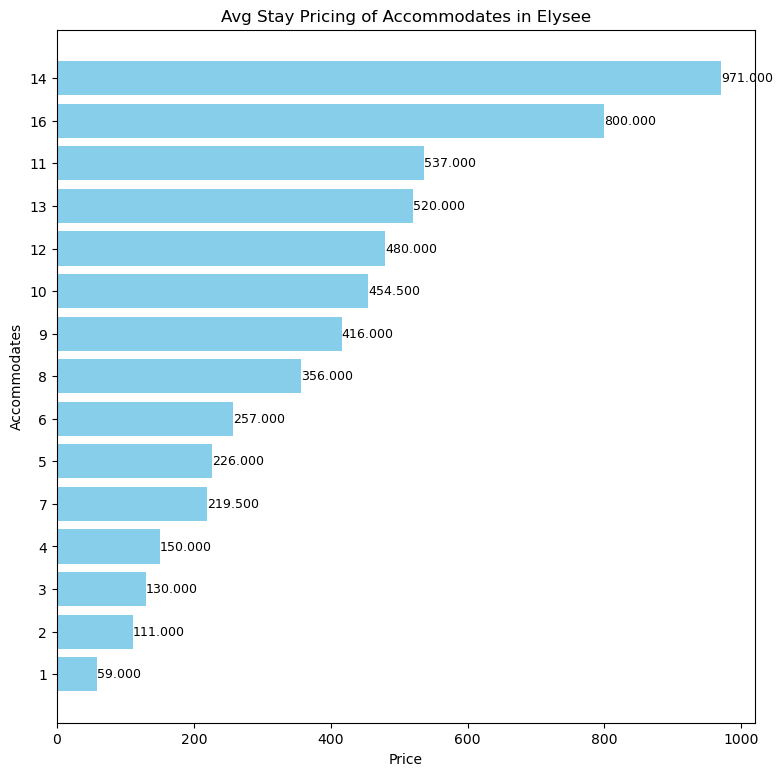

In [77]:
plt.figure(figsize=(9,9))
bars=plt.barh(df_clean_accommodates.index.astype(str), df_clean_accommodates['price'], color='skyblue')
plt.xlabel('Price')
plt.ylabel('Accommodates')
plt.title('Avg Stay Pricing of Accommodates in Elysee')
for bar in bars:
    plt.text(bar.get_width()+0.1,bar.get_y()+bar.get_height()/2,f"{bar.get_width():,.3f}", va='center',fontsize=9)

plt.yticks(np.arange(len(df_clean_accommodates)),labels=df_clean_accommodates.index)

plt.show()

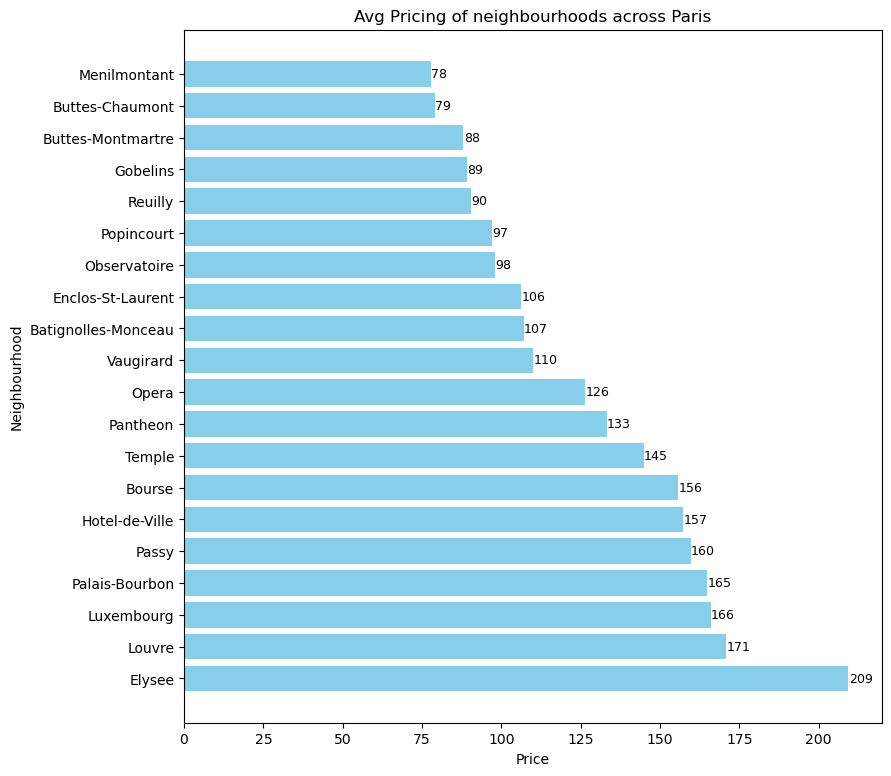

In [78]:
plt.figure(figsize=(9,9))
bars=plt.barh(df_clean_neighbourhood.index, df_clean_neighbourhood['price'], color='skyblue')
plt.xlabel('Price')
plt.ylabel('Neighbourhood')
plt.title('Avg Pricing of neighbourhoods across Paris')
for bar in bars:
    plt.text(bar.get_width()+0.1,bar.get_y()+bar.get_height()/2,f"{bar.get_width():,.0f}", va='center',fontsize=9)
plt.show()

<Axes: xlabel='instant_bookable', ylabel='log_price'>

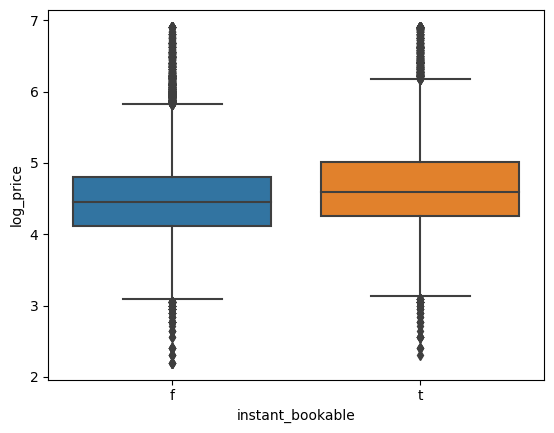

In [79]:
sns.boxplot(x='instant_bookable', y='log_price', data=df_clean)

<Axes: xlabel='is_large_listing', ylabel='price'>

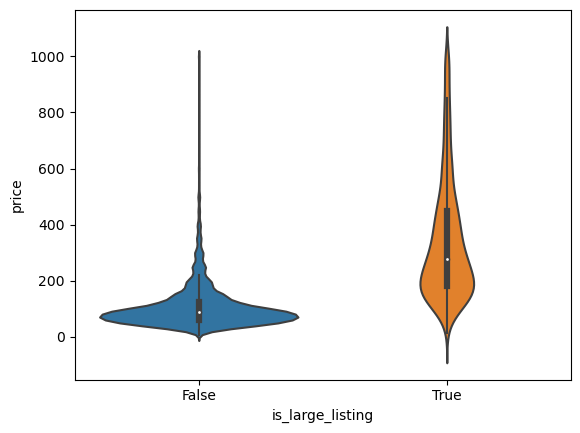

In [80]:
sns.violinplot(x='is_large_listing', y='price', data=df_clean)

Large listings are not just more expensive — they also have much higher variability, including premium/luxury segments.

## Numerical-Numerical Analysis

### Time Series Analysis: Market Growth

In [81]:
listings_over_time = (
    df_clean
    .set_index('host_since')
    .resample('Y')
    .agg(
        new_listings=('price', 'size'),
        median_price=('price', 'median')
    )
)

listings_over_time

,new_listings,median_price
host_since,,
2008-12-31,2,102.5
2009-12-31,86,130.0
2010-12-31,349,109.0
2011-12-31,1150,95.0
2012-12-31,3973,90.0
2013-12-31,6707,88.0
2014-12-31,8745,81.0
2015-12-31,9392,80.0
2016-12-31,6741,85.0


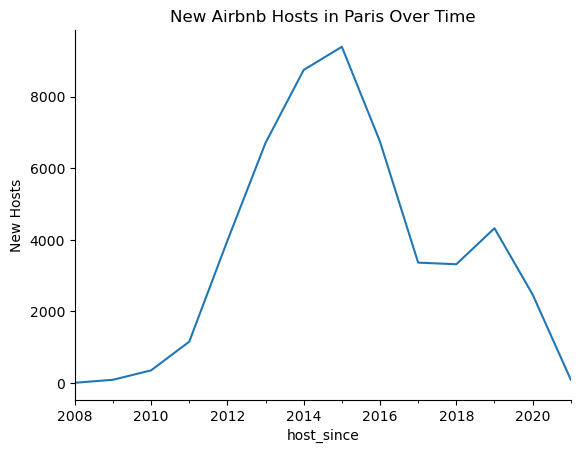

In [82]:
listings_over_time['new_listings'].plot(ylabel='New Hosts', title='New Airbnb Hosts in Paris Over Time')
sns.despine()

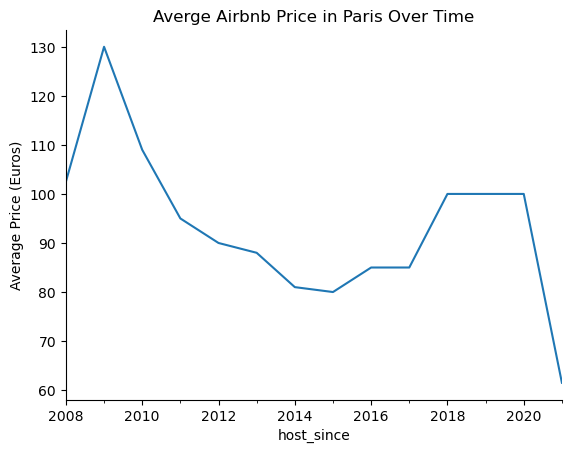

In [83]:
listings_over_time['median_price'].plot(ylabel='Average Price (Euros)', title='Averge Airbnb Price in Paris Over Time')
sns.despine()

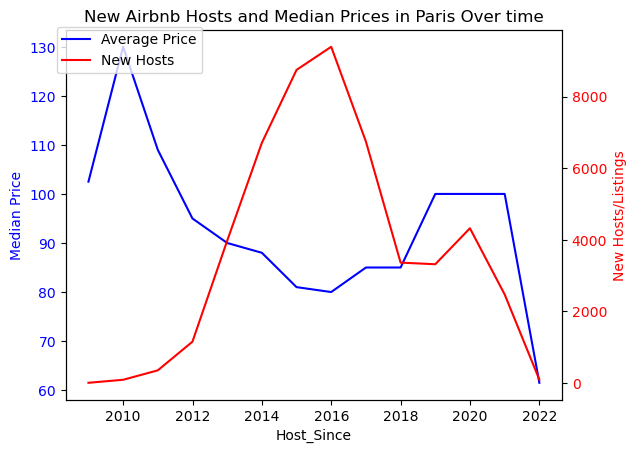

In [84]:
fig, ax1 = plt.subplots()

# Plot the first dataset on the primary y-axis (ax1)
ax1.plot(listings_over_time.index, listings_over_time['median_price'], color='blue', label='Average Price')
ax1.set_xlabel('Host_Since')
ax1.set_ylabel('Median Price', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


ax2 = ax1.twinx()


ax2.plot(listings_over_time.index, listings_over_time['new_listings'], color='red', label='New Hosts')
ax2.set_ylabel('New Hosts/Listings', color='red')
ax2.tick_params(axis='y', labelcolor='red')


plt.title('New Airbnb Hosts and Median Prices in Paris Over time')
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9)) # Adjust legend position as needed


plt.show()

## Supply vs Pricing Dynamics Over Time

To understand the evolution of the Paris Airbnb market, we analyze the relationship between listing supply (new hosts) and pricing trends (median price) over time.

A dual-axis time series plot is used to compare:

   * Median listing price (blue) — representing pricing power
   * Number of new listings (red) — representing supply growth
   
### Key Insights
   * **Supply Expansion Drives Price Decline (2012–2016)**:
   
        The number of new listings increased rapidly during this period, while median prices steadily declined.
        This suggests that **increased competition among hosts reduced pricing power**, leading to lower prices.
        
   * **Market Saturation Phase**:
        Around the peak of listing growth (2015–2016), median prices reached their lowest levels.
        This indicates **a saturated market**, where excess supply outweighed demand.
        
   * **Supply Contraction Enables Price Recovery (Post-2016)**:
        As the number of new listings began to decline, median prices gradually increased.
        This reflects **a rebalancing of supply and demand**, restoring pricing power for hosts.
        
   * **External Shock Impact (2020–2021)**:
        A sharp drop in new listings is observed, along with fluctuations in pricing.
        This likely corresponds to **external disruptions (e.g., COVID-19)** affecting both supply and demand.
        
### Key Takeaway

- The Paris Airbnb market is strongly influenced by **supply dynamics**, where rapid growth in listings leads to price compression, while reduced competition enables price recovery.

This highlights that **market saturation and competition play a more critical role in pricing than individual listing characteristics alone**.

#### Note

A dual-axis plot is used for visualization purposes. Since both axes have different scales, the relationship should be interpreted in terms of **overall trends rather than exact numerical comparison**.

<Axes: xlabel='accommodates', ylabel='price'>

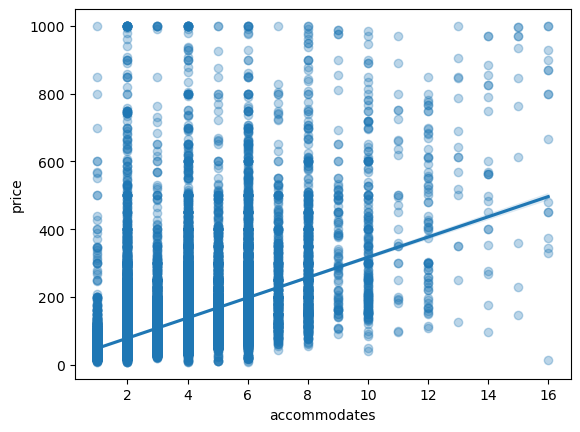

In [85]:
sns.regplot(x='accommodates', y='price', data=df_clean, scatter_kws={'alpha':0.3})

<Axes: xlabel='accommodates', ylabel='log_price'>

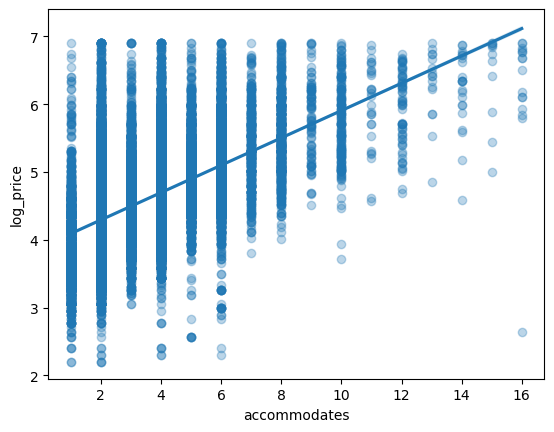

In [86]:
sns.regplot(x='accommodates', y='log_price', data=df_clean, scatter_kws={'alpha':0.3})

<Axes: xlabel='accommodates', ylabel='price'>

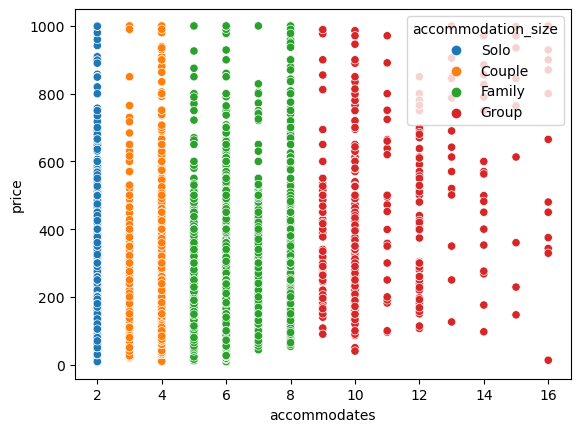

In [87]:
sns.scatterplot(y='price', x='accommodates', hue='accommodation_size', data=df_clean)

In [88]:
df_clean['bedrooms'].value_counts().sort_index()

bedrooms
1.0    37522
2.0     9493
3.0     2846
4.0      692
5.0      131
6.0       30
7.0        7
9.0        1
Name: count, dtype: int64

<Axes: xlabel='bedrooms', ylabel='price'>

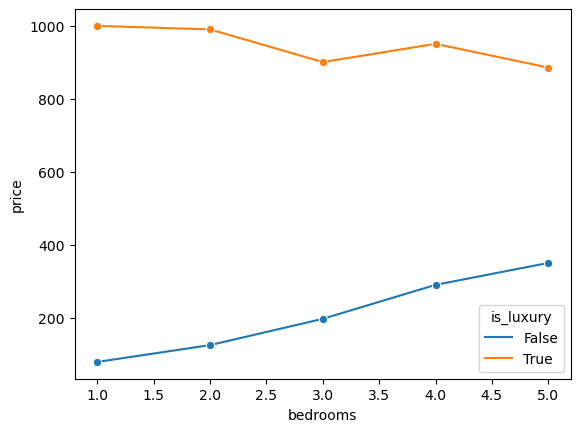

In [89]:
df_plot = df_clean[df_clean['bedrooms'] <= 5]

sns.lineplot(
    x='bedrooms',
    y='price',
    hue='is_luxury',
    data=df_plot,
    estimator='median',
    errorbar=None,
    marker='o'
)

### Price Trends by Bedrooms (≤5) and Luxury Status

To ensure reliable insights, the analysis is limited to listings with up to 5 bedrooms, as higher bedroom categories have very few observations.

Non-luxury listings exhibit a clear positive relationship between property size and price, with median prices increasing steadily as the number of bedrooms rises.

In contrast, luxury listings maintain consistently high prices across all bedroom categories, showing minimal dependence on size. This indicates that luxury status is a dominant pricing factor, outweighing the effect of additional bedrooms.

Overall, the price gap between luxury and non-luxury listings remains substantial and relatively stable across bedroom counts.

Text(0.5, 1.0, 'Spatial Distribution of Airbnb Prices (Log-Transformed)')

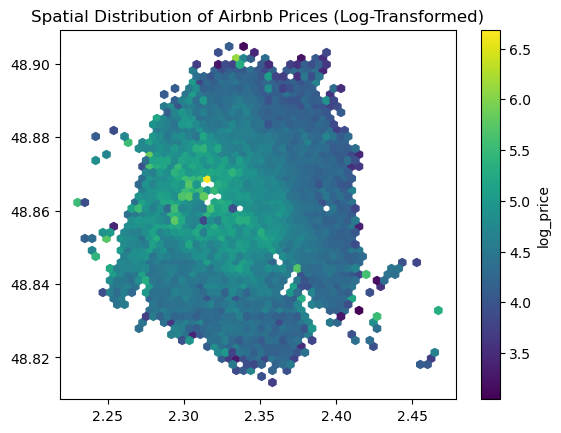

In [90]:
plt.hexbin(
    df_clean['longitude'],
    df_clean['latitude'],
    C=np.log1p(df_clean['price']),  # smoother than log_price column
    gridsize=50,
    cmap='viridis'
)
plt.colorbar(label='log_price')
plt.title("Spatial Distribution of Airbnb Prices (Log-Transformed)")

### Where Are High-Value Listings Located?

The geographic distribution of prices reveals a clear spatial pricing gradient across Paris.

Higher-priced listings are concentrated in central areas, while peripheral regions tend to exhibit relatively lower prices.

Using a log-transformed price scale (log1p) reduces the impact of extreme values and allows for a clearer visualization of underlying pricing patterns.

This highlights a smoother and more realistic gradient, showing that location plays a meaningful role in determining listing value.

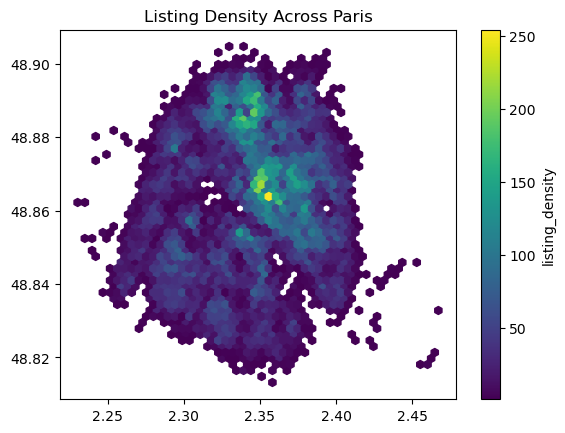

In [91]:
plt.hexbin(
    df_clean['longitude'],
    df_clean['latitude'],
    gridsize=50,
    cmap='viridis',
    mincnt=1 
)
plt.title("Listing Density Across Paris")
plt.colorbar(label='listing_density')

In [92]:
df_clean['neighbourhood'].value_counts().head(6)

neighbourhood
Buttes-Montmartre      5841
Popincourt             4816
Enclos-St-Laurent      3725
Vaugirard              3703
Batignolles-Monceau    3404
Buttes-Chaumont        3068
Name: count, dtype: int64

### Where Are Airbnb Listings Concentrated Across Paris?

The geographic distribution of listings reveals clear supply clusters across Paris.

While central Paris remains a key hub driven by tourism demand, several northeastern neighborhoods such as Buttes-Chaumont, Ménilmontant, and Popincourt exhibit high listing density. 

This indicates that Airbnb supply is not solely concentrated in premium central locations, but also in residential areas where property availability and lower entry barriers enable higher listing volumes.

Overall, listing density is influenced by both demand-driven central regions and supply-driven residential clusters.

### How Listing Density and Pricing Interact

Comparing listing density and pricing patterns reveals that high supply does not always translate to high prices.

While central Paris combines both high listing density and high prices, several outer residential clusters show high listing density but relatively lower prices.

This suggests that supply concentration alone does not determine pricing power. Instead, pricing is influenced by a combination of location desirability, property characteristics, and market demand.

In essence, central areas benefit from both strong demand and pricing premiums, whereas residential clusters are more supply-driven with competitive pricing.

## Correlations

In [93]:
df_clean[['review_scores_rating','review_scores_cleanliness','review_scores_location','review_scores_value']].corr()

,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value
review_scores_rating,1.000000,0.700461,0.444207,0.730831
review_scores_cleanliness,0.700461,1.000000,0.345358,0.591139
review_scores_location,0.444207,0.345358,1.000000,0.434342
review_scores_value,0.730831,0.591139,0.434342,1.000000


### Review Score Correlation Analysis

Strong positive correlations were observed between overall rating and both value (~0.73) and cleanliness (~0.70), 
indicating that guests prioritize perceived value and hygiene over other factors.

Location shows a comparatively weaker correlation (~0.44), suggesting that while it matters, 
it is not the primary driver of guest satisfaction.

This highlights that hosts can achieve high ratings even outside premium neighbourhoods 
by focusing on cleanliness and delivering strong value for money.

In [94]:
df_clean.select_dtypes(include='number').corr()

,latitude,longitude,accommodates,bedrooms,price,minimum_nights,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,price_per_person,host_experience,log_price
latitude,1.000000,0.088009,-0.021463,-0.018404,-0.044244,-0.021648,-0.000127,-0.010248,-0.138416,0.007508,-0.041718,0.040398,-0.066834
longitude,0.088009,1.000000,-0.033573,-0.037911,-0.172690,-0.020772,0.018148,-0.008253,-0.104396,0.033359,-0.161677,0.086033,-0.211541
accommodates,-0.021463,-0.033573,1.000000,0.720894,0.489683,-0.002989,-0.051575,-0.038144,-0.011215,-0.080887,-0.154673,-0.015886,0.540073
bedrooms,-0.018404,-0.037911,0.720894,1.000000,0.501348,0.013224,0.014174,0.014679,-0.000996,-0.020428,0.011030,0.029045,0.513767
price,-0.044244,-0.172690,0.489683,0.501348,1.000000,-0.017446,0.033092,0.070941,0.076680,-0.042887,0.669891,-0.066398,0.876099
minimum_nights,-0.021648,-0.020772,-0.002989,0.013224,-0.017446,1.000000,0.000008,-0.016537,-0.000205,-0.012639,-0.026898,0.056612,-0.023919
review_scores_rating,-0.000127,0.018148,-0.051575,0.014174,0.033092,0.000008,1.000000,0.700461,0.444207,0.730831,0.082549,0.104198,0.059579
review_scores_cleanliness,-0.010248,-0.008253,-0.038144,0.014679,0.070941,-0.016537,0.700461,1.000000,0.345358,0.591139,0.119074,0.062172,0.104663
review_scores_location,-0.138416,-0.104396,-0.011215,-0.000996,0.076680,-0.000205,0.444207,0.345358,1.000000,0.434342,0.100882,0.004874,0.115210
review_scores_value,0.007508,0.033359,-0.080887,-0.020428,-0.042887,-0.012639,0.730831,0.591139,0.434342,1.000000,0.012775,0.100447,-0.036722


### Highly Correlated Variables

In [95]:
corr = df_clean.select_dtypes(include='number').corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0':'var1', 'level_1':'var2', 0:'correlation'})
)

high_corr = high_corr[high_corr['correlation'] > 0.5]

high_corr.sort_values(by='correlation', ascending=False)

,var1,var2,correlation
49,price,log_price,0.876099
59,review_scores_rating,review_scores_value,0.730831
23,accommodates,bedrooms,0.720894
57,review_scores_rating,review_scores_cleanliness,0.700461
47,price,price_per_person,0.669891
64,review_scores_cleanliness,review_scores_value,0.591139
76,price_per_person,log_price,0.583661
32,accommodates,log_price,0.540073
41,bedrooms,log_price,0.513767
33,bedrooms,price,0.501348


Text(0.5, 1.0, 'Median Price by Neighbourhood and Room Type')

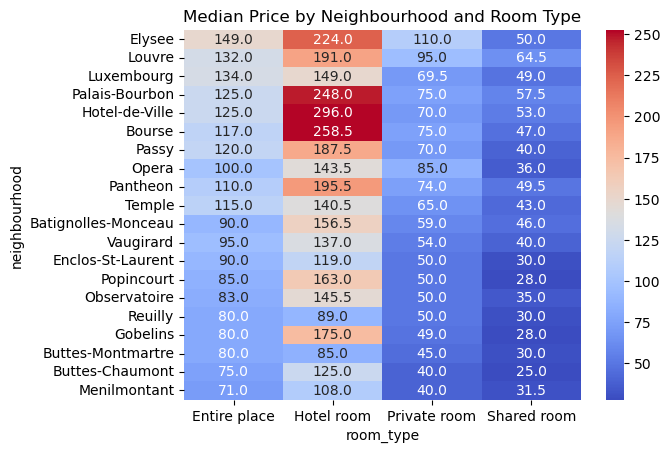

In [96]:
pivot2 = df_clean.pivot_table(
    values='price',
    index='neighbourhood',
    columns='room_type',
    aggfunc='median'
)

pivot2['overall_median_pricing'] = pivot2.median(axis=1)

pivot2 = pivot2.sort_values('overall_median_pricing',ascending=False)

#pivot = pivot.sort_values('Entire place', ascending=False)

pivot2.drop(columns='overall_median_pricing',inplace=True)

sns.heatmap(pivot2, cmap='coolwarm', annot=True, fmt=".1f" , robust=True)
plt.title("Median Price by Neighbourhood and Room Type")

Neighbourhood rankings remain largely consistent across different sorting methods 
(entire place vs overall median), with the top 5 neighbourhoods unchanged.

This indicates that high-priced neighbourhoods maintain their premium status 
across all room types, suggesting a strong location-driven pricing effect 
rather than room-type-specific pricing anomalies.

Across all neighbourhoods, hotel rooms consistently command the highest median prices, often exceeding entire homes , suggesting premium positioning or service-based pricing strategies.

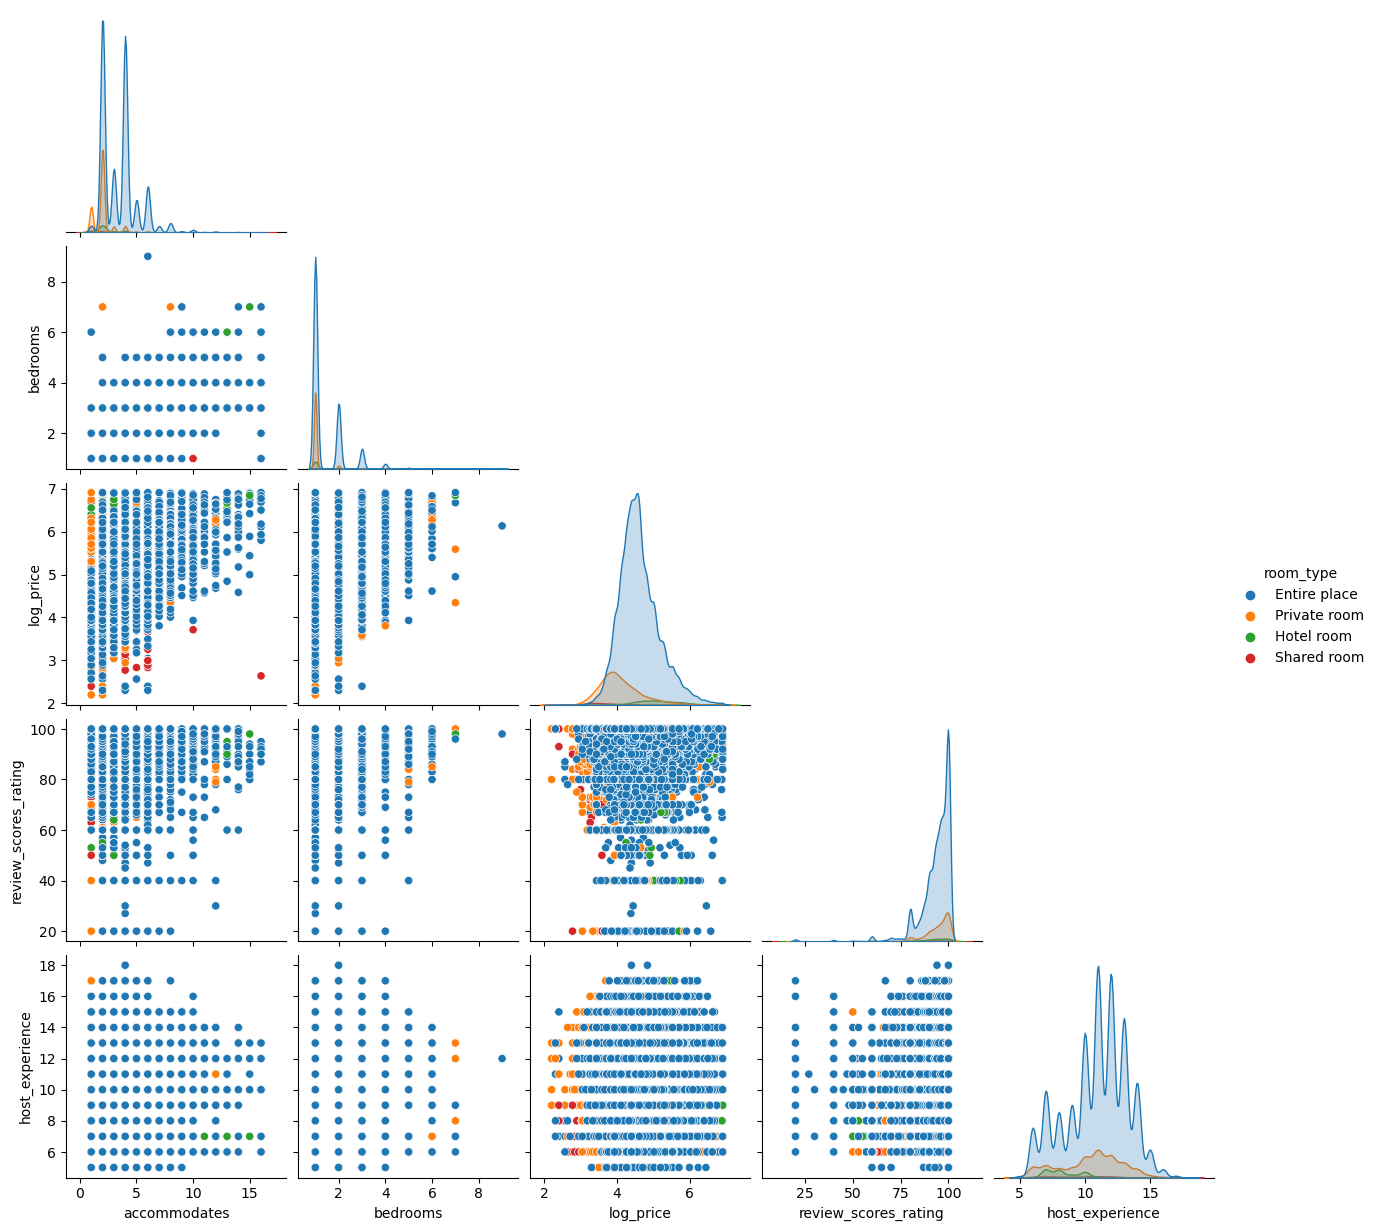

In [97]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn.axisgrid")
numeric_df = df_clean[['accommodates','bedrooms','log_price','review_scores_rating','host_experience','room_type']]
sns.pairplot(numeric_df,hue='room_type', corner=True)
plt.show()

## Final Insights & Business Implications

The Paris Airbnb market reveals several strong structural patterns:

### 1. Pricing is Dominated by Listing Segmentation, Not Just Size
- While price increases with bedrooms and accommodates, this relationship is primarily observed in non-luxury listings.
- Luxury listings maintain consistently high prices regardless of size, indicating that **market positioning (luxury vs standard) is a stronger driver of price than property size alone**.

### 2. Market is Clearly Segmented by Room Type
- Private rooms cater primarily to solo travelers and operate in a lower price band.
- Entire homes dominate family and group stays and capture the majority of mid-to-high price ranges.
- Hotel-style listings behave like professional inventory, forming a distinct high-efficiency segment.

### 3. Professional Hosts Operate Differently from Individual Hosts
- Listings resembling hotel operations show significantly higher instant booking adoption (~90%+), indicating optimized, scalable operations.
- Individual hosts rely more on manual approval, reflecting a more controlled and less standardized approach.

### 4. Location Creates a Strong Pricing Gradient
- Spatial analysis reveals a clear concentration of high-priced listings in central Paris.
- While listing characteristics drive baseline pricing, **location amplifies pricing power**, especially in premium areas.

### 5. Superhosts Optimize for Booking Efficiency
- Superhosts tend to prefer shorter minimum stays, suggesting a strategy focused on increasing booking frequency and review accumulation.

---

## Overall Conclusion

The Paris Airbnb market is driven by a combination of **listing segmentation, host strategy, and location effects**.

- **Segmentation (luxury vs standard)** is the strongest determinant of pricing behavior  
- **Property size influences price within segments, but does not define premium positioning**  
- **Location acts as a multiplier**, enhancing pricing potential in high-demand areas  

These patterns highlight a market where **strategic positioning and operational efficiency matter more than just property size**.

In [98]:
superhost_premium = (
    df_clean.groupby('host_is_superhost')['price'].median()
)

premium_pct = (
    (superhost_premium['t'] - superhost_premium['f']) 
    / superhost_premium['f']
) * 100

premium_pct

16.27906976744186

In [99]:
exp_premium = (
    df_clean.groupby('host_exp_bin')['price'].median()
)

exp_growth_pct = (
    (exp_premium['high'] - exp_premium['low']) 
    / exp_premium['low']
) * 100

exp_growth_pct

19.565217391304348

In [100]:
df_clean.groupby(['host_exp_bin','host_is_superhost'])['price'].median().unstack()

host_is_superhost,f,t
host_exp_bin,,
low,90.0,101.0
med,80.0,98.0
high,109.0,120.0


In [101]:
((98-80)/80)*100

22.5

- The superhost premium is strongest in the **mid-experience segment (~22.5%)**, indicating that reputation plays a critical role where pricing power is otherwise weaker.

## Business Recommendations

Based on the analysis of pricing patterns across host characteristics, the following actionable insights emerge:

### 1. Prioritize Superhost Conversion Programs
   * Superhosts consistently achieve higher listing prices across all segments, with a statistically significant impact.
   * The effect is especially strong for mid-experience hosts, where reputation compensates for weaker pricing power.

#### Recommendation:

   * Encourage hosts to achieve superhost status through:
        * Faster response times
        * Higher review ratings
        * Consistent booking performance

#### Business Impact:

   * Platform-wide increase in listing prices
   * Improved customer trust and booking likelihood
   
### 2. Target Mid-Experience Hosts for Optimization
   * Hosts with 10–15 years of experience show unexpectedly lower pricing, indicating inefficiencies.
   * However, superhost status significantly boosts their pricing potential.

#### Recommendation:

   * Provide targeted support for mid-experience hosts:
       * Pricing guidance tools
       * Listing optimization suggestions
       * Dynamic pricing recommendations

#### Business Impact:

   * Unlock underutilized revenue segment
   * Improve host earnings without requiring new supply
   
### 3. Leverage Highly Experienced Hosts as Premium Segment
   * Hosts with 15+ years of experience command the highest prices, regardless of superhost status.

#### Recommendation:

   * Position these listings as premium inventory
   * Highlight them in search rankings or premium categories

#### Business Impact:

   * Increase average booking value
   * Improve perceived platform quality
   
### 4. Promote Experience-Based Pricing Strategies

   * Pricing is influenced by both host experience and reputation, not just property features.

       - Superhosts charge approximately **16.3% higher median prices** than non-superhosts.
       - Highly experienced hosts (15+ years) charge **~19.6% higher prices** than low-experience hosts.
       - The superhost premium persists across all experience levels, reinforcing the value of reputation.

#### Recommendation:
   * Introduce data-driven pricing insights for hosts, such as:
        - “Superhosts in your segment earn ~16% higher prices”
        - “Top-experience hosts earn ~20% more than new hosts”

#### Business Impact:
   * Encourages data-driven pricing decisions  
   * Improves pricing efficiency across listings  
   * Increases overall platform revenue through better price optimization

### 5. Improve Pricing Stability in Mid-Tier Segment
   * The non-linear pricing trend (dip in medium experience) suggests:
       * Market competition
       * Suboptimal pricing strategies

#### Recommendation:

   * Introduce:
       * Automated pricing tools
       * Competitor benchmarking dashboards

#### Business Impact:

   * Reduce pricing inefficiencies
   * Improve revenue consistency